# Asset Value Analysis - Matching CDS Spread Companies

This notebook recreates the CDS spread distribution plots but for **asset values** from the Merton model.
The key feature: it matches the exact companies used in the CDS spread calculations for each maturity at each moment in time.

In [1]:
# Setup
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.utils import config

print(f"✓ Project root: {project_root}")
print(f"✓ Data directory: {config.DATA_DIR}")
print(f"✓ Output directory: {config.OUTPUT_DIR}")

✓ Project root: /Users/thomasdeleeuw/Downloads/Seminar-QF/Seminar QF
✓ Data directory: /Users/thomasdeleeuw/Downloads/Seminar-QF/Seminar QF/data
✓ Output directory: /Users/thomasdeleeuw/Downloads/Seminar-QF/Seminar QF/data/output


In [2]:
# Load the merged data with Merton model outputs
merged_data_path = config.OUTPUT_DIR / 'merged_data_with_merton.csv'
df_merged = pd.read_csv(merged_data_path, parse_dates=['date'])

print(f"✓ Loaded merged data: {len(df_merged):,} rows")
print(f"  Date range: {df_merged['date'].min()} to {df_merged['date'].max()}")
print(f"  Unique firms: {df_merged['gvkey'].nunique()}")
print(f"\nColumns: {', '.join(df_merged.columns)}")
print(f"\nFirst few rows:")
df_merged.head()

✓ Loaded merged data: 133,008 rows
  Date range: 2010-01-04 00:00:00 to 2024-12-31 00:00:00
  Unique firms: 34

Columns: country, isin, date, company, gvkey, shares_out, close, mkt_cap, fdate, liabilities_total, risk_free_rate, asset_value, asset_volatility

First few rows:


,country,isin,date,company,gvkey,shares_out,close,mkt_cap,fdate,liabilities_total,risk_free_rate,asset_value,asset_volatility
0,FRA,FR0000121014,2010-01-04,LVMH MOET HENNESSY LOUIS V,14447,490166554.0,78.70,3.857611e+10,NaN,NaN,0.012322,NaN,NaN
1,FRA,FR0000121014,2010-01-05,LVMH MOET HENNESSY LOUIS V,14447,490166554.0,78.33,3.839475e+10,NaN,NaN,0.012322,NaN,NaN
2,FRA,FR0000121014,2010-01-06,LVMH MOET HENNESSY LOUIS V,14447,490166554.0,79.09,3.876727e+10,NaN,NaN,0.012322,NaN,NaN
3,FRA,FR0000121014,2010-01-07,LVMH MOET HENNESSY LOUIS V,14447,490166554.0,79.99,3.920842e+10,NaN,NaN,0.012322,NaN,NaN
4,FRA,FR0000121014,2010-01-08,LVMH MOET HENNESSY LOUIS V,14447,490166554.0,81.07,3.973780e+10,NaN,NaN,0.012322,NaN,NaN


In [3]:
# Load CDS market data to determine which companies are available for each maturity
def load_cds_market_data(filepath, maturity):
    """Load CDS market data from Excel file."""
    df = pd.read_excel(filepath, header=None)
    
    # Row 3 has company names, data starts at row 5
    company_names_raw = df.iloc[3, 2:].tolist()
    company_names = []
    for name in company_names_raw:
        if pd.notna(name):
            clean = name.split(' SNR ')[0] if ' SNR ' in str(name) else str(name)
            company_names.append(clean)
        else:
            company_names.append(None)
    
    # Get dates and data
    dates = pd.to_datetime(df.iloc[5:, 0], errors='coerce')
    data = df.iloc[5:, 2:].copy()
    data.columns = company_names[:len(data.columns)]
    data['date'] = dates.values
    
    # Melt to long format
    data_long = data.melt(
        id_vars=['date'], 
        var_name='company_cds', 
        value_name=f'cds_market_{maturity}y_bps'
    )
    data_long[f'cds_market_{maturity}y_bps'] = pd.to_numeric(
        data_long[f'cds_market_{maturity}y_bps'], errors='coerce'
    )
    
    return data_long.dropna(subset=['date', 'company_cds'])

# Company name mapping (CDS data name -> Model data name)
COMPANY_MAPPING = {
    'ADIDAS AG': 'ADIDAS AG',
    'AIR LIQUIDE SA': "L'AIR LIQUIDE SA",
    'AIRBUS SE': 'AIRBUS SE',
    'ALLIANZ SE': 'ALLIANZ SE',
    'ANHEUSER-BUSCH INBE': 'ANHEUSER-BUSCH INBEV',
    'AXA': 'AXA SA',
    'BASF SE': 'BASF SE',
    'BAYER AG': 'BAYER AG',
    'BAYER MOTOREN WERKE': 'BAYERISCHE MOTOREN WERKE AKT',
    'BNP PARIBAS SNRFOR MM14 E - CDS PREM. MID': 'BNP PARIBAS',
    'DANONE SA': 'DANONE SA',
    'DEUTSCHE POST AG': 'DEUTSCHE POST AG',
    'DEUTSCHE TELEKOM AG': 'DEUTSCHE TELEKOM',
    'ENEL S.P.A.': 'ENEL SPA',
    'ENI S.P.A.': 'ENI SPA',
    'IBERDROLA, S.A.': 'IBERDROLA SA',
    'INFINEON TECS': 'INFINEON TECHNOLOGIES AG',
    'ING GROEP N.V.': 'ING GROEP NV',
    'INTESA SANPAOLO SPA': 'INTESA SANPAOLO SPA',
    'KERING SA': 'KERING SA',
    'KON AHOLD DELHAIZE': 'KONINKLIJKE AHOLD DELHAIZE',
    "L'OREAL": 'LOREAL SA',
    'LVMH MOET HENNESSY': 'LVMH MOET HENNESSY LOUIS V',
    'MUNICH REINSURANCE': 'MUNICH RE CO',
    'NOKIA OYJ': 'NOKIA OYJ',
    'ORANGE S.A.': 'ORANGE SA',
    'SANOFI SA': 'SANOFI',
    'SAP SE': 'SAP SE',
    'SCHNEIDER ELECTRIC': 'SCHNEIDER ELECTRIC S E',
    'SIEMENS AG': 'SIEMENS AG',
    'TOTALENERGIES SE': 'TOTALENERGIES SE',
    'UNICREDIT SPA': 'UNICREDIT SPA',
    'VINCI': 'VINCI SA',
    'WOLTERS KLUWER NV': 'WOLTERS KLUWER NV',
}

# Load CDS data for all maturities
input_dir = config.DATA_DIR / 'input'
cds_1y = load_cds_market_data(input_dir / 'CDS_1y_mat_data.xlsx', 1)
cds_3y = load_cds_market_data(input_dir / 'CDS_3y_mat_data.xlsx', 3)
cds_5y = load_cds_market_data(input_dir / 'CDS_5y_mat_data.xlsx', 5)

# Merge all maturities
market_cds = cds_1y.merge(cds_3y, on=['date', 'company_cds'], how='outer')
market_cds = market_cds.merge(cds_5y, on=['date', 'company_cds'], how='outer')

# Add company name mapping
market_cds['company'] = market_cds['company_cds'].map(COMPANY_MAPPING)

# Get company to gvkey mapping
company_to_gvkey = df_merged[['company', 'gvkey']].drop_duplicates().set_index('company')['gvkey'].to_dict()

# Add gvkey to market data
market_cds['gvkey'] = market_cds['company'].map(company_to_gvkey)
market_cds = market_cds.dropna(subset=['gvkey'])
market_cds['gvkey'] = market_cds['gvkey'].astype(int)

print(f"✓ Loaded market CDS data: {len(market_cds):,} observations")
print(f"  Unique firms: {market_cds['gvkey'].nunique()}")
print(f"  Date range: {market_cds['date'].min()} to {market_cds['date'].max()}")

✓ Loaded market CDS data: 146,090 observations
  Unique firms: 34
  Date range: 2010-01-01 00:00:00 to 2025-12-31 00:00:00


In [4]:
def get_firms_with_cds_data(date, maturity):
    """
    Get the set of firms (gvkeys) that have CDS data for a specific date and maturity.
    
    Parameters:
    -----------
    date : pd.Timestamp or str
        The date to check
    maturity : int
        The maturity in years (1, 3, or 5)
    
    Returns:
    --------
    set : Set of gvkeys that have non-null CDS spreads for this date/maturity
    """
    col_name = f'cds_market_{maturity}y_bps'
    date_data = market_cds[market_cds['date'] == pd.Timestamp(date)]
    firms_with_data = date_data[date_data[col_name].notna()]['gvkey'].unique()
    return set(firms_with_data)

# Test the function
test_date = '2020-03-15'
for mat in [1, 3, 5]:
    firms = get_firms_with_cds_data(test_date, mat)
    print(f"Date: {test_date}, Maturity: {mat}Y -> {len(firms)} firms with CDS data")

Date: 2020-03-15, Maturity: 1Y -> 0 firms with CDS data
Date: 2020-03-15, Maturity: 3Y -> 0 firms with CDS data
Date: 2020-03-15, Maturity: 5Y -> 0 firms with CDS data


In [8]:
def analyze_asset_values_matching_cds_firms(maturity=5, start_date='2017-06-01'):
    """
    Analyze asset values over time, using only the firms that have CDS data for the specified maturity.
    This creates plots matching the CDS spread distribution analysis but for asset values.
    
    Parameters:
    -----------
    maturity : int
        The maturity in years (1, 3, or 5) - determines which firms to include at each date
    start_date : str
        Start date for the analysis (default: '2017-06-01' to match CDS plots)
    """
    # Get all unique dates in the merged data, filtered by start_date
    all_dates = df_merged[df_merged['date'] >= pd.Timestamp(start_date)]['date'].sort_values().unique()
    
    # For each date, get statistics for firms that have CDS data for this maturity
    results = []
    
    for date in all_dates:
        # Get firms with CDS data for this maturity on this date
        cds_firms = get_firms_with_cds_data(date, maturity)
        
        if len(cds_firms) == 0:
            continue
        
        # Get asset values for these firms on this date
        date_data = df_merged[
            (df_merged['date'] == date) & 
            (df_merged['gvkey'].isin(cds_firms)) &
            (df_merged['asset_value'].notna())
        ]
        
        if len(date_data) == 0:
            continue
        
        # Calculate statistics (convert to billions for readability)
        asset_values_bn = date_data['asset_value'] / 1e9
        
        results.append({
            'date': date,
            'num_firms': len(cds_firms),
            'num_firms_with_asset': len(date_data),
            'mean': asset_values_bn.mean(),
            'median': asset_values_bn.median(),
            'q25': asset_values_bn.quantile(0.25),
            'q75': asset_values_bn.quantile(0.75),
            'std': asset_values_bn.std()
        })
    
    daily_stats = pd.DataFrame(results)
    
    # Create the plots
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    fig.suptitle(f'Asset Value Analysis - Matching {maturity}Y CDS Firms', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # Plot 1: Number of firms
    axes[0].plot(daily_stats['date'], daily_stats['num_firms'], linewidth=2, color='blue', label='Firms with CDS data')
    axes[0].set_title(f'Number of Firms in Dataset Over Time', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Number of Firms', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.5, label='COVID Start')
    axes[0].legend()
    
    # Plot 2: Mean vs Median asset values
    axes[1].plot(daily_stats['date'], daily_stats['mean'], linewidth=2, label='Mean', color='orange', alpha=0.8)
    axes[1].plot(daily_stats['date'], daily_stats['median'], linewidth=2, label='Median', color='blue', alpha=0.8)
    axes[1].set_title(f'Mean vs Median Asset Values ({maturity}Y)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Asset Value (billions)', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[1].axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.5)
    
    # Plot 3: Distribution (25th, 50th, 75th percentiles)
    axes[2].fill_between(daily_stats['date'], daily_stats['q25'], daily_stats['q75'], 
                         alpha=0.3, color='lightblue', label='25th-75th percentile')
    axes[2].plot(daily_stats['date'], daily_stats['median'], linewidth=2, label='Median', color='blue')
    axes[2].set_title(f'Asset Value Distribution (25th, 50th, 75th percentiles)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Date', fontsize=12)
    axes[2].set_ylabel('Asset Value (billions)', fontsize=12)
    axes[2].legend(fontsize=11)
    axes[2].grid(True, alpha=0.3)
    axes[2].axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    return daily_stats

print("✓ Function 'analyze_asset_values_matching_cds_firms' defined")

✓ Function 'analyze_asset_values_matching_cds_firms' defined


In [ ]:
def plot_asset_value_distribution(maturity=5, start_date='2017-06-01'):
    """
    Plot asset value distribution over time (mean, median, and quartiles).
    Matches the companies used in CDS spread calculations for the specified maturity.
    
    Parameters:
    -----------
    maturity : int
        The maturity in years (1, 3, or 5) - determines which firms to include
    start_date : str
        Start date for the analysis (default: '2017-06-01' to match CDS plots)
    """
    # Get all unique dates, filtered by start_date
    all_dates = df_merged[df_merged['date'] >= pd.Timestamp(start_date)]['date'].sort_values().unique()
    
    results = []
    for date in all_dates:
        # Get firms with CDS data for this maturity on this date
        cds_firms = get_firms_with_cds_data(date, maturity)
        
        if len(cds_firms) == 0:
            continue
        
        # Get asset values for these firms
        date_data = df_merged[
            (df_merged['date'] == date) & 
            (df_merged['gvkey'].isin(cds_firms)) &
            (df_merged['asset_value'].notna())
        ]
        
        if len(date_data) == 0:
            continue
        
        # Convert to billions for readability
        asset_values_bn = date_data['asset_value'] / 1e9
        
        results.append({
            'date': date,
            'mean': asset_values_bn.mean(),
            'median': asset_values_bn.median(),
            'q25': asset_values_bn.quantile(0.25),
            'q75': asset_values_bn.quantile(0.75)
        })
    
    daily_stats = pd.DataFrame(results)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Plot mean (thicker line, most important)
    ax.plot(daily_stats['date'], daily_stats['mean'], 
            linewidth=2.5, label='Mean', color='#d62728', alpha=0.9)
    
    # Plot median
    ax.plot(daily_stats['date'], daily_stats['median'], 
            linewidth=2, label='Median (50th percentile)', color='#1f77b4', alpha=0.8)
    
    # Plot 25th and 75th percentiles
    ax.plot(daily_stats['date'], daily_stats['q75'], 
            linewidth=1.5, label='75th percentile', color='#2ca02c', alpha=0.7, linestyle='--')
    ax.plot(daily_stats['date'], daily_stats['q25'], 
            linewidth=1.5, label='25th percentile', color='#ff7f0e', alpha=0.7, linestyle='--')
    
    # Fill area between 25th and 75th percentiles
    ax.fill_between(daily_stats['date'], daily_stats['q25'], daily_stats['q75'], 
                     alpha=0.15, color='gray', label='Interquartile range (25th-75th)')
    
    # Add vertical line for COVID start
    ax.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle=':', 
               alpha=0.5, linewidth=2, label='COVID-19 Start')
    
    # Labels and formatting
    ax.set_title(f'Asset Value Distribution Over Time ({maturity}-Year Maturity)\n' +
                 'Mean, Median, and Quartiles',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Asset Value (billions)', fontsize=12)
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*90}")
    print(f"SUMMARY STATISTICS: Asset Values - {maturity}Y Maturity")
    print(f"{'='*90}")
    
    periods = [
        ('2020-03-01', '2020-05-31', 'COVID Peak (Mar-May 2020)'),
        ('2023-01-01', '2023-03-31', 'Banking Crisis (Jan-Mar 2023)'),
        ('2024-01-01', '2024-12-31', 'Recent Period (2024)'),
    ]
    
    print(f"\n{'Period':<30} {'Mean':<12} {'Median':<12} {'25th %':<12} {'75th %':<12} {'Spread':<12}")
    print(f"{'':<30} {'(billions)':<12} {'(billions)':<12} {'(billions)':<12} {'(billions)':<12} {'Q75-Q25':<12}")
    print("-"*90)
    
    for start, end, label in periods:
        period_data = daily_stats[(daily_stats['date'] >= start) & (daily_stats['date'] <= end)]
        if not period_data.empty:
            mean_avg = period_data['mean'].mean()
            median_avg = period_data['median'].mean()
            q25_avg = period_data['q25'].mean()
            q75_avg = period_data['q75'].mean()
            spread = q75_avg - q25_avg
            
            print(f"{label:<30} {mean_avg:>11.2f}  {median_avg:>11.2f}  {q25_avg:>11.2f}  {q75_avg:>11.2f}  {spread:>11.2f}")
    
    print(f"\n💡 Key Insight:")
    print(f"   Asset values represent the total value of a firm's assets estimated using Merton model.")
    print(f"   The interquartile range (Q75-Q25) shows the spread of the middle 50% of firms.")
    print(f"   Only firms with {maturity}Y CDS data are included at each point in time.")
    
    return daily_stats

print("✓ Function 'plot_asset_value_distribution' defined")

✓ Function 'plot_asset_value_distribution' defined


## Analysis for 5-Year Maturity

These plots show asset values for firms that have 5-year CDS data.

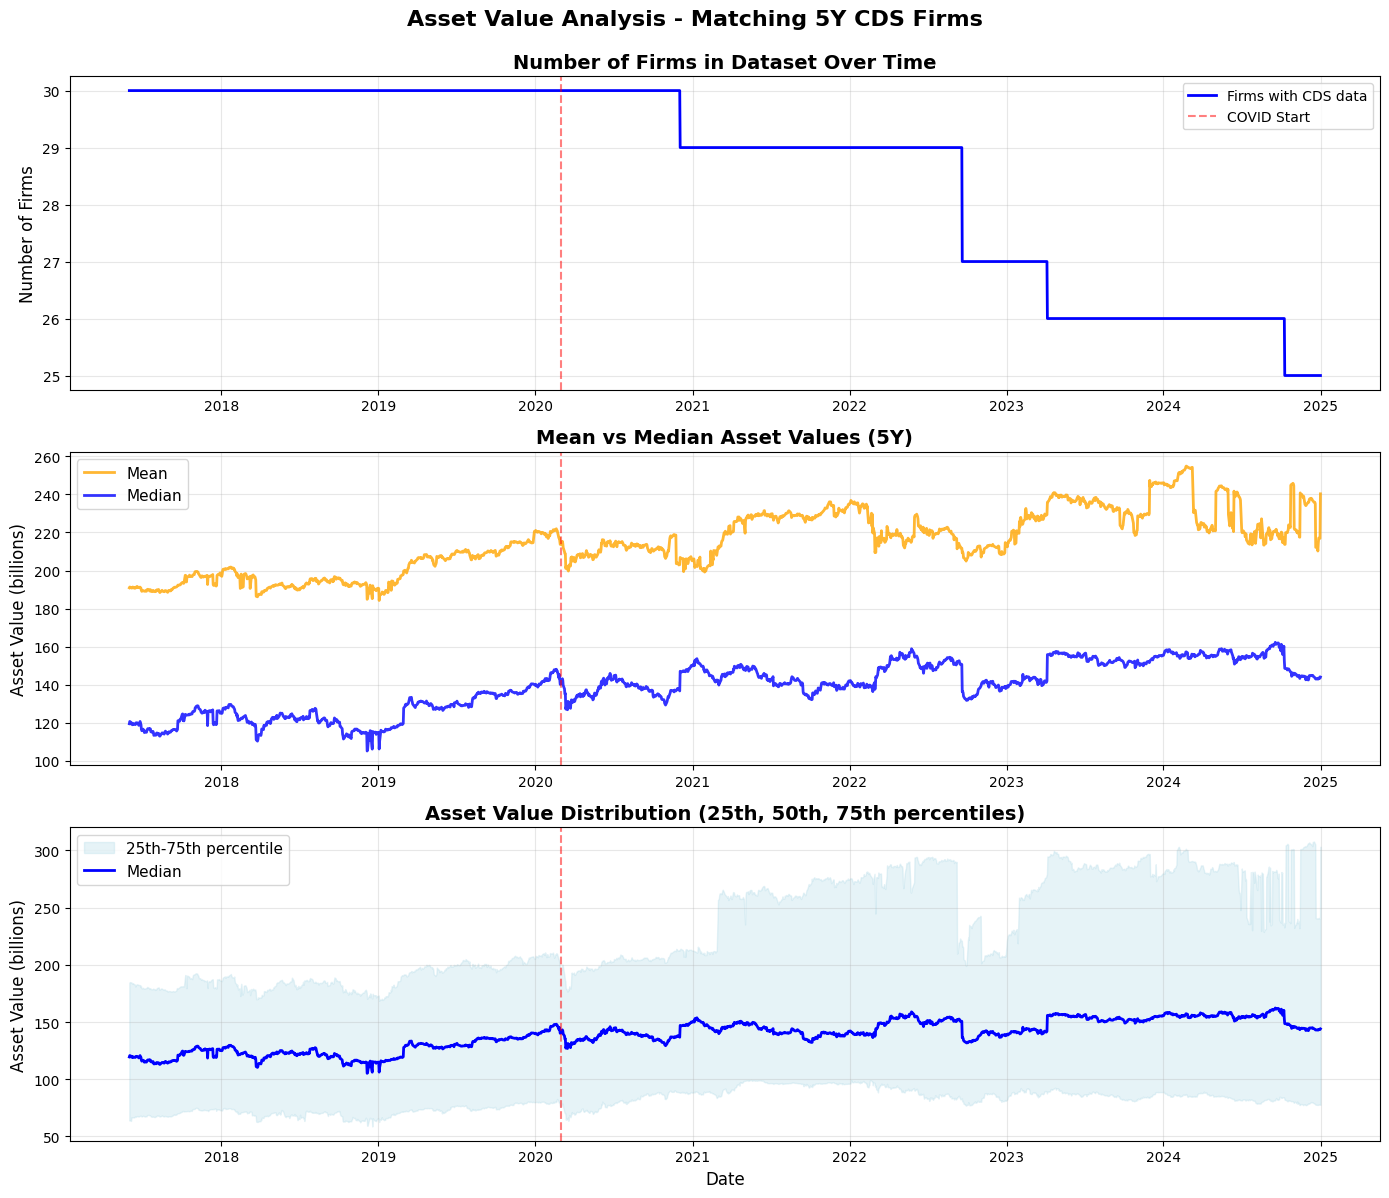

In [9]:
# Plot 1: Three-panel analysis for 5Y maturity
stats_5y = analyze_asset_values_matching_cds_firms(maturity=5)

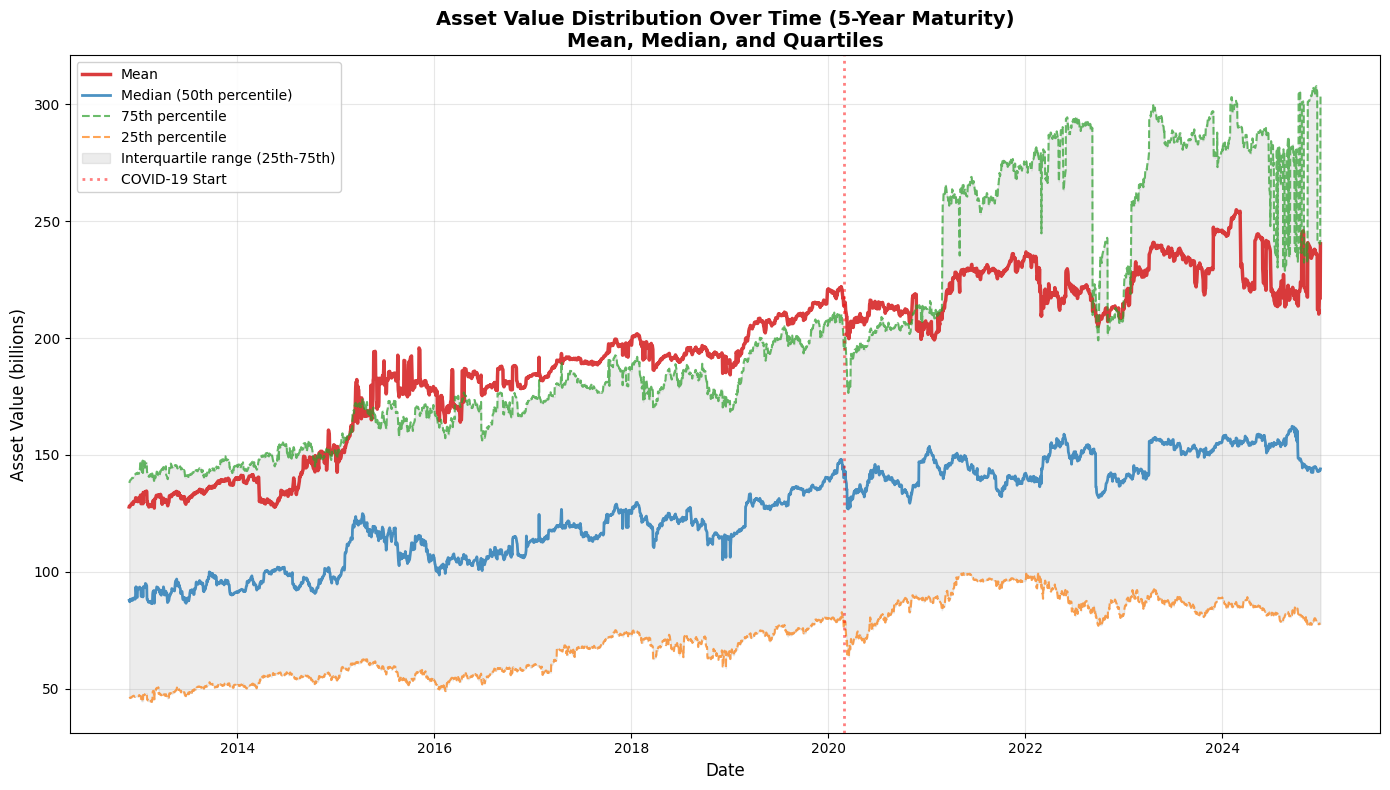


SUMMARY STATISTICS: Asset Values - 5Y Maturity

Period                         Mean         Median       25th %       75th %       Spread      
                               (billions)   (billions)   (billions)   (billions)   Q75-Q25     
------------------------------------------------------------------------------------------
COVID Peak (Mar-May 2020)           207.47       134.30        71.29       193.00       121.71
Banking Crisis (Jan-Mar 2023)       224.48       141.82        87.96       252.66       164.69
Recent Period (2024)                230.93       153.69        82.93       279.05       196.12

💡 Key Insight:
   Asset values represent the total value of a firm's assets estimated using Merton model.
   The interquartile range (Q75-Q25) shows the spread of the middle 50% of firms.
   Only firms with 5Y CDS data are included at each point in time.


In [10]:
# Plot 2: Distribution statistics for 5Y maturity
dist_stats_5y = plot_asset_value_distribution(maturity=5)

## Analysis for 3-Year Maturity

These plots show asset values for firms that have 3-year CDS data.

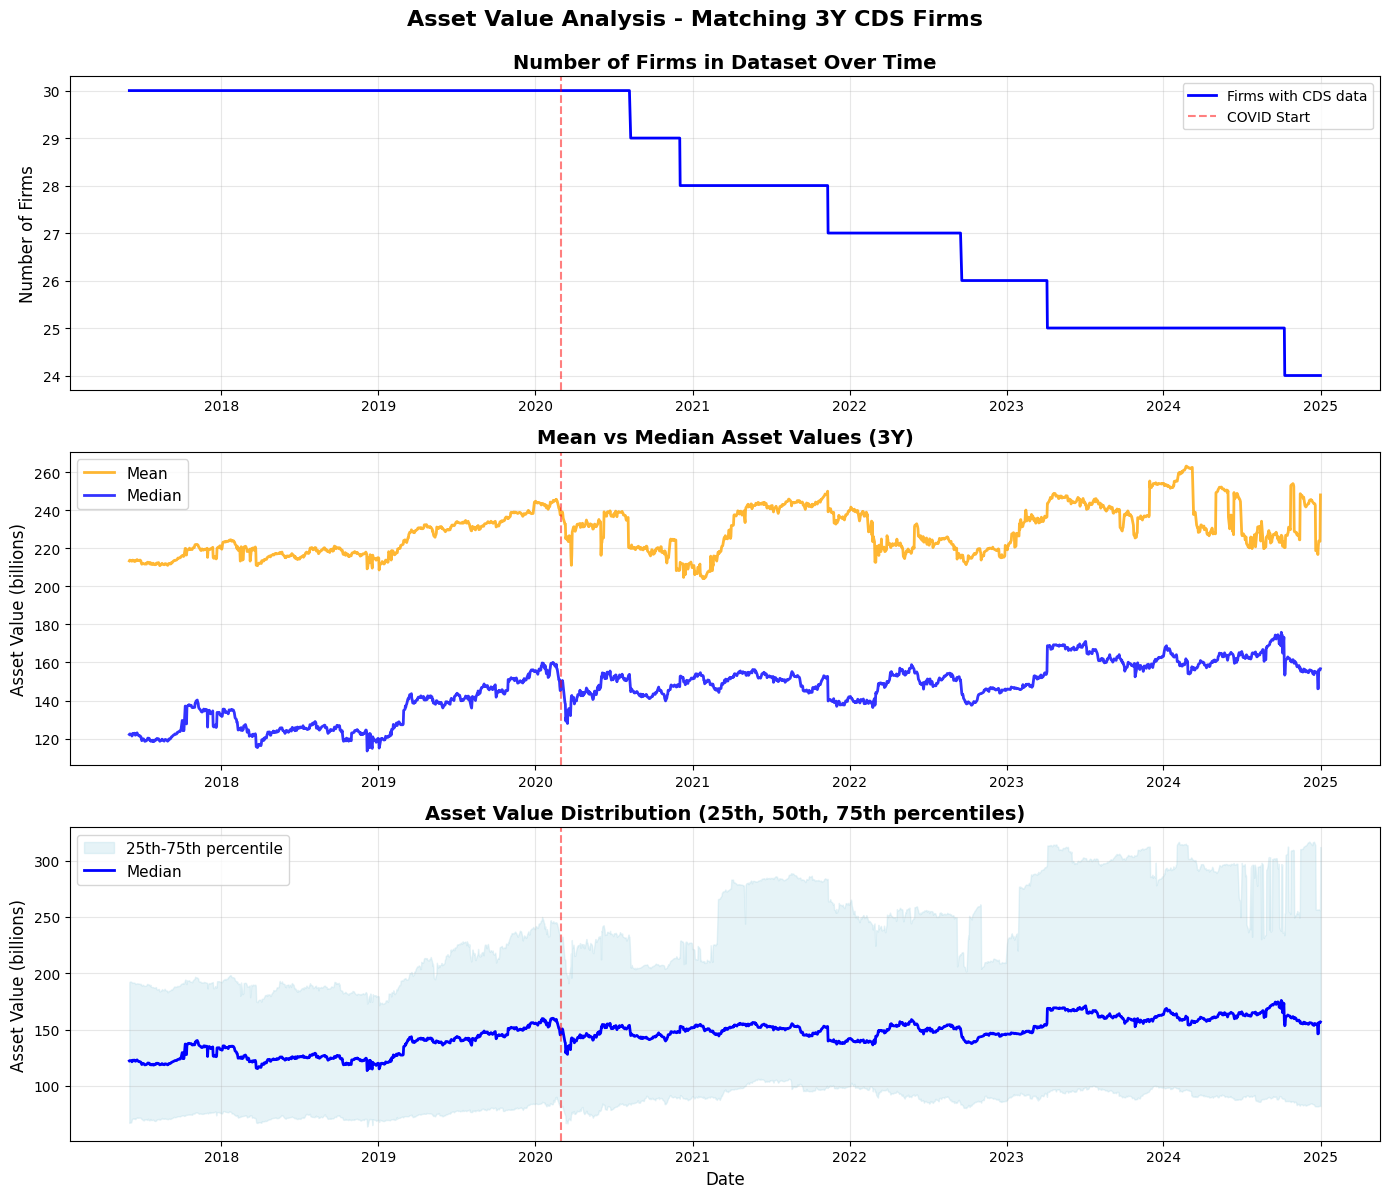

In [11]:
# Plot 1: Three-panel analysis for 3Y maturity
stats_3y = analyze_asset_values_matching_cds_firms(maturity=3)

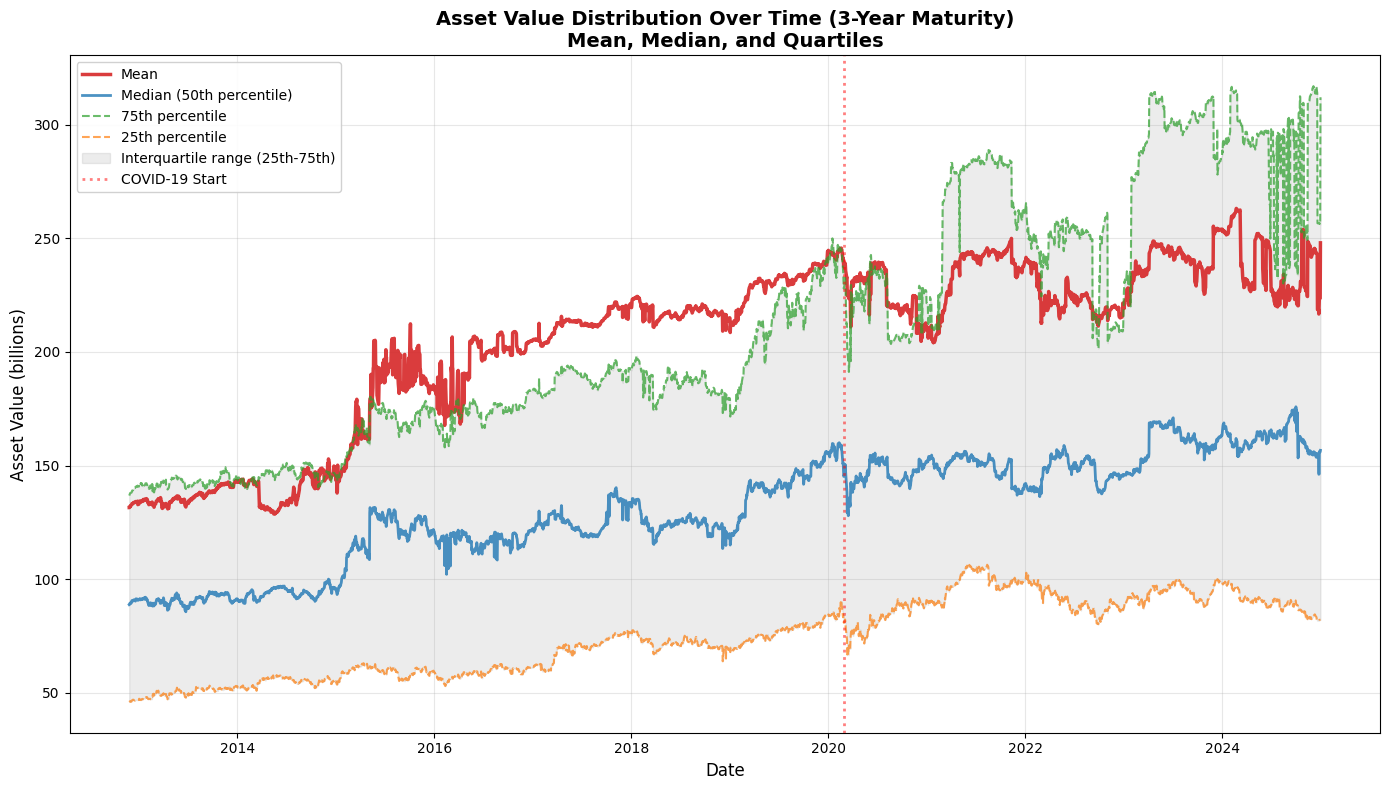


SUMMARY STATISTICS: Asset Values - 3Y Maturity

Period                         Mean         Median       25th %       75th %       Spread      
                               (billions)   (billions)   (billions)   (billions)   Q75-Q25     
------------------------------------------------------------------------------------------
COVID Peak (Mar-May 2020)           230.87       142.18        75.47       220.83       145.36
Banking Crisis (Jan-Mar 2023)       231.57       148.72        90.99       267.79       176.80
Recent Period (2024)                238.17       161.86        89.83       289.80       199.97

💡 Key Insight:
   Asset values represent the total value of a firm's assets estimated using Merton model.
   The interquartile range (Q75-Q25) shows the spread of the middle 50% of firms.
   Only firms with 3Y CDS data are included at each point in time.


In [12]:
# Plot 2: Distribution statistics for 3Y maturity
dist_stats_3y = plot_asset_value_distribution(maturity=3)

## Analysis for 1-Year Maturity

These plots show asset values for firms that have 1-year CDS data.

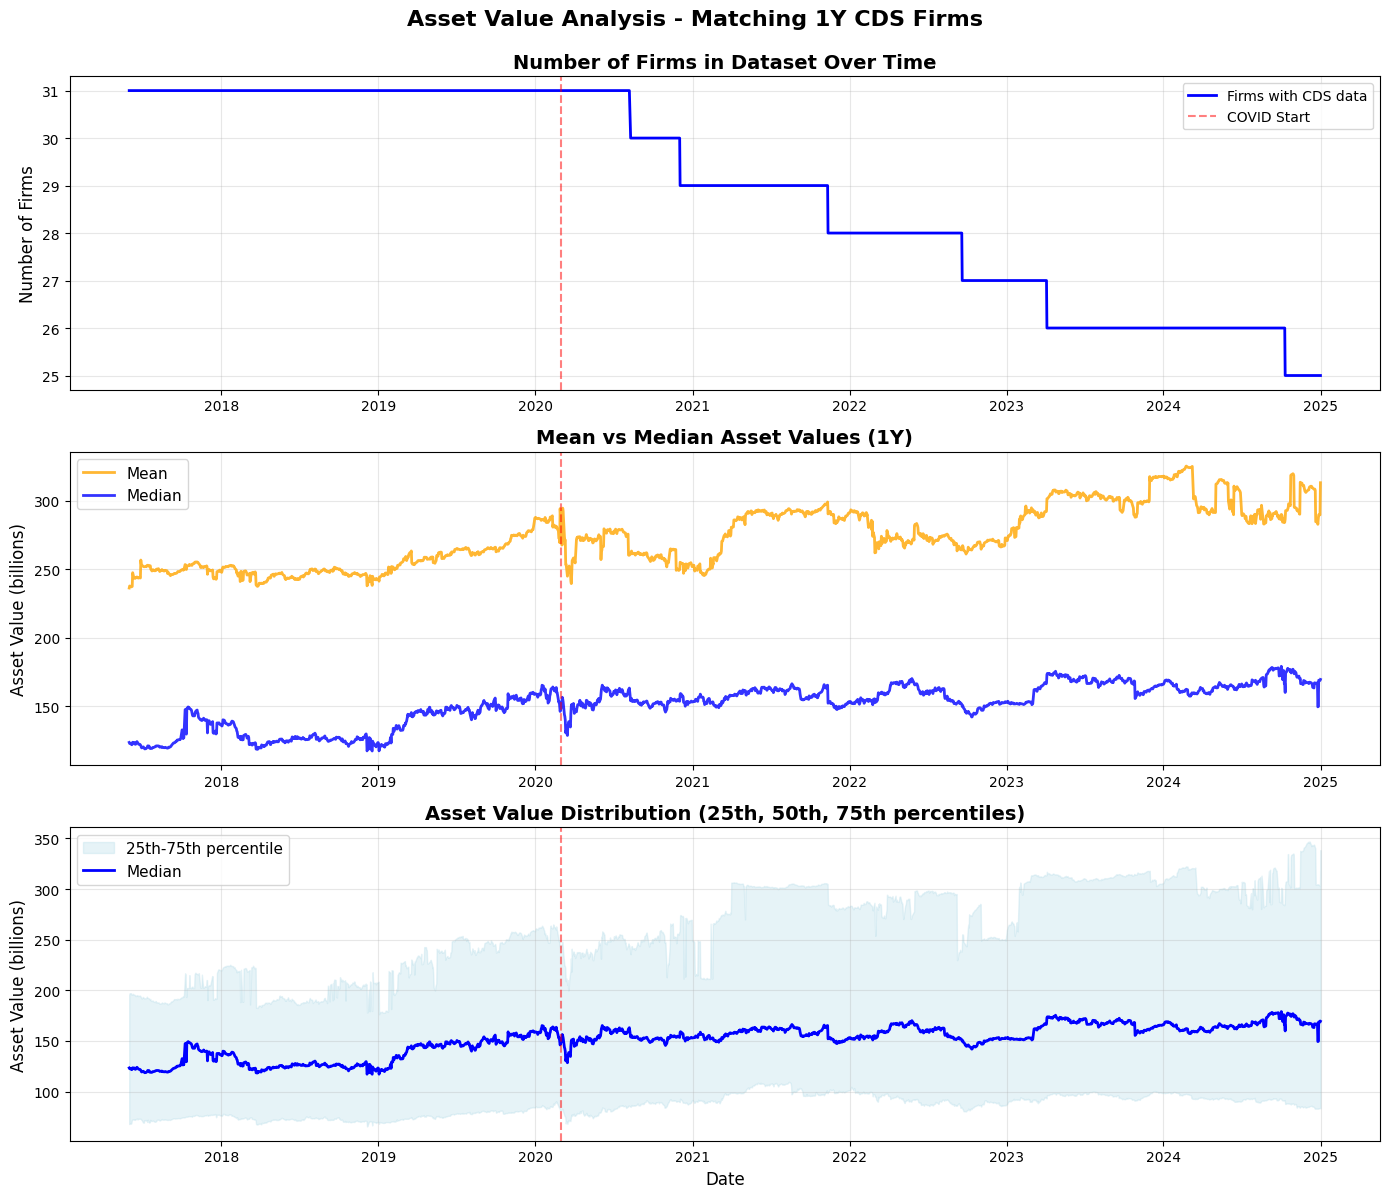

In [13]:
# Plot 1: Three-panel analysis for 1Y maturity
stats_1y = analyze_asset_values_matching_cds_firms(maturity=1)

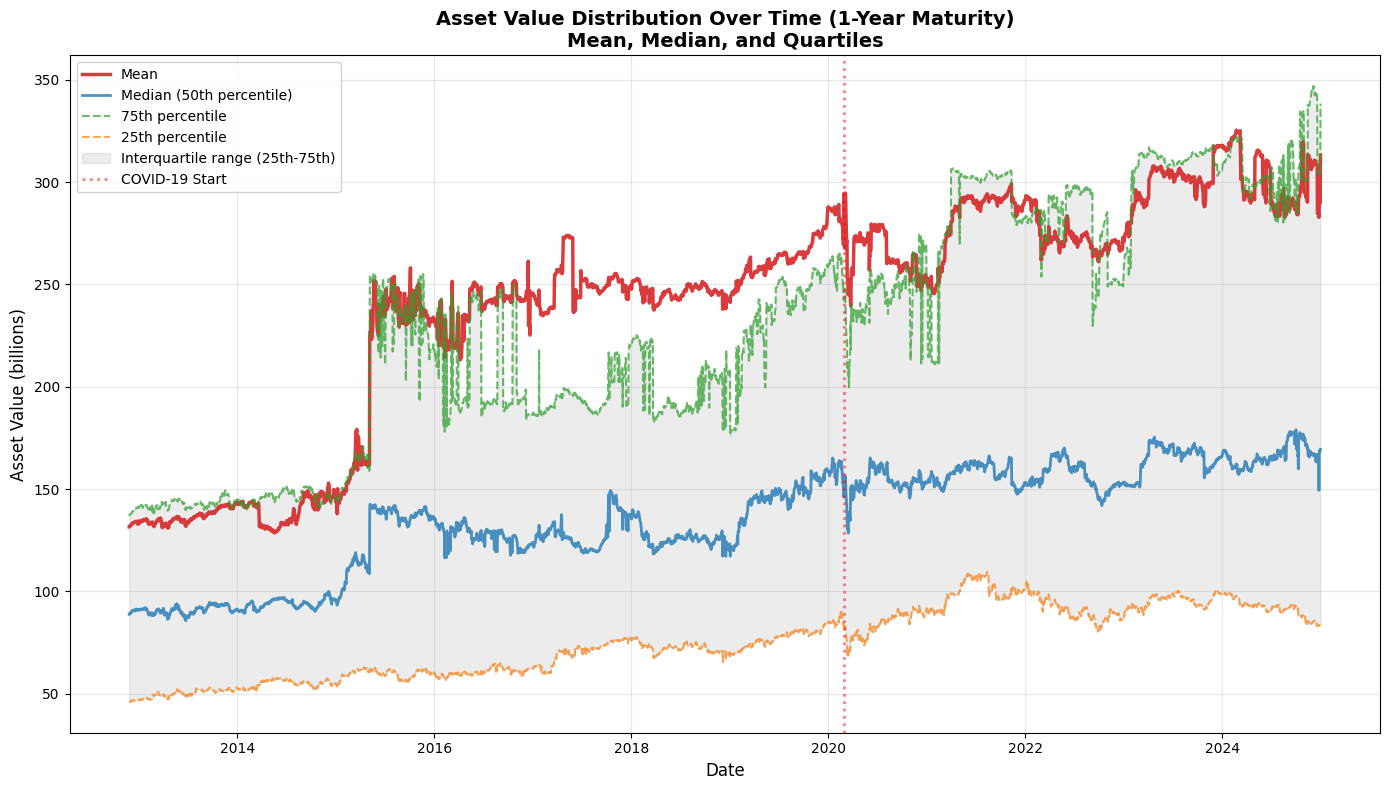


SUMMARY STATISTICS: Asset Values - 1Y Maturity

Period                         Mean         Median       25th %       75th %       Spread      
                               (billions)   (billions)   (billions)   (billions)   Q75-Q25     
------------------------------------------------------------------------------------------
COVID Peak (Mar-May 2020)           267.26       148.38        76.68       233.01       156.33
Banking Crisis (Jan-Mar 2023)       286.08       155.63        91.67       294.93       203.26
Recent Period (2024)                301.74       166.42        91.86       308.31       216.45

💡 Key Insight:
   Asset values represent the total value of a firm's assets estimated using Merton model.
   The interquartile range (Q75-Q25) shows the spread of the middle 50% of firms.
   Only firms with 1Y CDS data are included at each point in time.


In [14]:
# Plot 2: Distribution statistics for 1Y maturity
dist_stats_1y = plot_asset_value_distribution(maturity=1)

## Compare Asset Values Across Maturities

This section compares how asset values differ when we filter for different maturity CDS data availability.

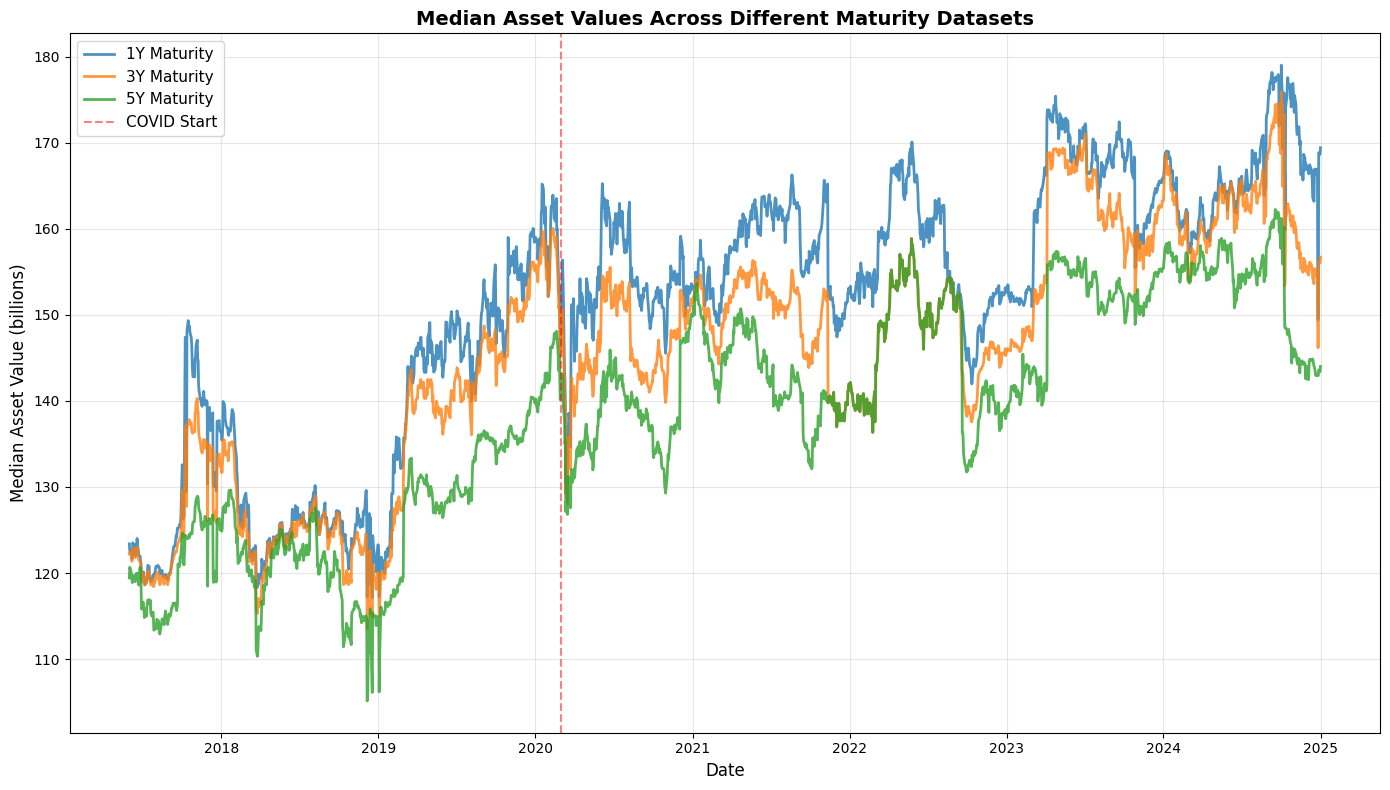

In [15]:
# Compare median asset values across all three maturities
fig, ax = plt.subplots(figsize=(14, 8))

start_date = pd.Timestamp('2017-06-01')

if 'stats_1y' in locals() and not stats_1y.empty:
    filtered_1y = stats_1y[stats_1y['date'] >= start_date]
    ax.plot(filtered_1y['date'], filtered_1y['median'], linewidth=2, label='1Y Maturity', alpha=0.8)
if 'stats_3y' in locals() and not stats_3y.empty:
    filtered_3y = stats_3y[stats_3y['date'] >= start_date]
    ax.plot(filtered_3y['date'], filtered_3y['median'], linewidth=2, label='3Y Maturity', alpha=0.8)
if 'stats_5y' in locals() and not stats_5y.empty:
    filtered_5y = stats_5y[stats_5y['date'] >= start_date]
    ax.plot(filtered_5y['date'], filtered_5y['median'], linewidth=2, label='5Y Maturity', alpha=0.8)

ax.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.5, label='COVID Start')
ax.set_title('Median Asset Values Across Different Maturity Datasets', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Median Asset Value (billions)', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

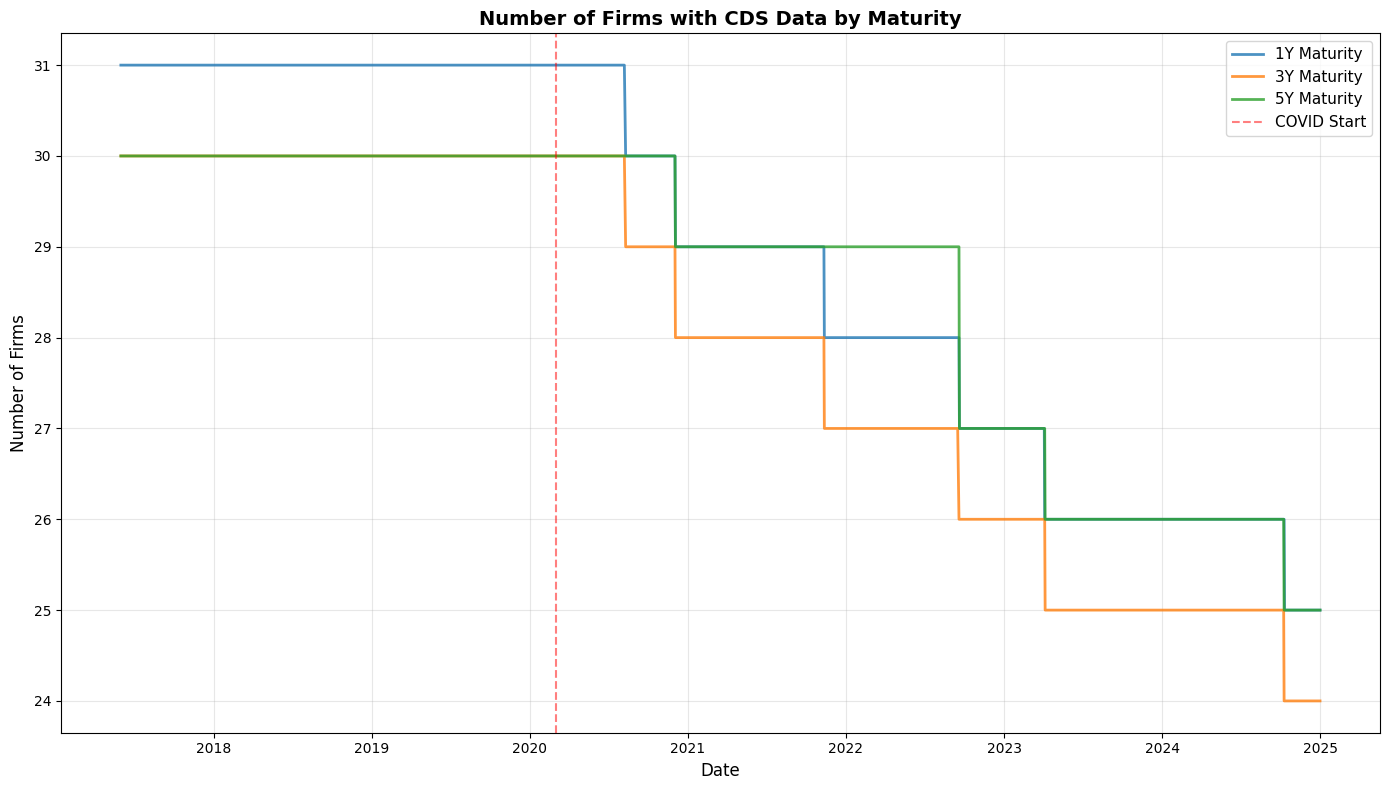

In [16]:
# Compare number of firms across maturities
fig, ax = plt.subplots(figsize=(14, 8))

start_date = pd.Timestamp('2017-06-01')

if 'stats_1y' in locals() and not stats_1y.empty:
    filtered_1y = stats_1y[stats_1y['date'] >= start_date]
    ax.plot(filtered_1y['date'], filtered_1y['num_firms'], linewidth=2, label='1Y Maturity', alpha=0.8)
if 'stats_3y' in locals() and not stats_3y.empty:
    filtered_3y = stats_3y[stats_3y['date'] >= start_date]
    ax.plot(filtered_3y['date'], filtered_3y['num_firms'], linewidth=2, label='3Y Maturity', alpha=0.8)
if 'stats_5y' in locals() and not stats_5y.empty:
    filtered_5y = stats_5y[stats_5y['date'] >= start_date]
    ax.plot(filtered_5y['date'], filtered_5y['num_firms'], linewidth=2, label='5Y Maturity', alpha=0.8)

ax.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.5, label='COVID Start')
ax.set_title('Number of Firms with CDS Data by Maturity', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Firms', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Market Cap Analysis

This section analyzes the **original market capitalization** from the Excel dataset, using only the firms that have CDS data for each maturity at each moment in time.

In [17]:
def analyze_market_cap_matching_cds_firms(maturity=5, start_date='2017-06-01'):
    """
    Analyze market capitalization over time, using only the firms that have CDS data for the specified maturity.
    This creates plots matching the CDS spread distribution analysis but for market cap.
    
    Parameters:
    -----------
    maturity : int
        The maturity in years (1, 3, or 5) - determines which firms to include at each date
    start_date : str
        Start date for the analysis (default: '2017-06-01' to match CDS plots)
    """
    # Get all unique dates in the merged data, filtered by start_date
    all_dates = df_merged[df_merged['date'] >= pd.Timestamp(start_date)]['date'].sort_values().unique()
    
    # For each date, get statistics for firms that have CDS data for this maturity
    results = []
    
    for date in all_dates:
        # Get firms with CDS data for this maturity on this date
        cds_firms = get_firms_with_cds_data(date, maturity)
        
        if len(cds_firms) == 0:
            continue
        
        # Get market cap for these firms on this date
        date_data = df_merged[
            (df_merged['date'] == date) & 
            (df_merged['gvkey'].isin(cds_firms)) &
            (df_merged['mkt_cap'].notna())
        ]
        
        if len(date_data) == 0:
            continue
        
        # Calculate statistics (convert to billions for readability)
        mkt_cap_bn = date_data['mkt_cap'] / 1e9
        
        results.append({
            'date': date,
            'num_firms': len(cds_firms),
            'num_firms_with_mktcap': len(date_data),
            'mean': mkt_cap_bn.mean(),
            'median': mkt_cap_bn.median(),
            'q25': mkt_cap_bn.quantile(0.25),
            'q75': mkt_cap_bn.quantile(0.75),
            'std': mkt_cap_bn.std()
        })
    
    daily_stats = pd.DataFrame(results)
    
    # Create the plots
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    fig.suptitle(f'Market Capitalization Analysis - Matching {maturity}Y CDS Firms', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # Plot 1: Number of firms
    axes[0].plot(daily_stats['date'], daily_stats['num_firms'], linewidth=2, color='blue', label='Firms with CDS data')
    axes[0].set_title(f'Number of Firms in Dataset Over Time', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Number of Firms', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.5, label='COVID Start')
    axes[0].legend()
    
    # Plot 2: Mean vs Median market cap
    axes[1].plot(daily_stats['date'], daily_stats['mean'], linewidth=2, label='Mean', color='orange', alpha=0.8)
    axes[1].plot(daily_stats['date'], daily_stats['median'], linewidth=2, label='Median', color='blue', alpha=0.8)
    axes[1].set_title(f'Mean vs Median Market Cap ({maturity}Y)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Market Cap (billions)', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[1].axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.5)
    
    # Plot 3: Distribution (25th, 50th, 75th percentiles)
    axes[2].fill_between(daily_stats['date'], daily_stats['q25'], daily_stats['q75'], 
                         alpha=0.3, color='lightblue', label='25th-75th percentile')
    axes[2].plot(daily_stats['date'], daily_stats['median'], linewidth=2, label='Median', color='blue')
    axes[2].set_title(f'Market Cap Distribution (25th, 50th, 75th percentiles)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Date', fontsize=12)
    axes[2].set_ylabel('Market Cap (billions)', fontsize=12)
    axes[2].legend(fontsize=11)
    axes[2].grid(True, alpha=0.3)
    axes[2].axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    return daily_stats

print("✓ Function 'analyze_market_cap_matching_cds_firms' defined")

✓ Function 'analyze_market_cap_matching_cds_firms' defined


In [18]:
def plot_market_cap_distribution(maturity=5, start_date='2017-06-01'):
    """
    Plot market capitalization distribution over time (mean, median, and quartiles).
    Matches the companies used in CDS spread calculations for the specified maturity.
    
    Parameters:
    -----------
    maturity : int
        The maturity in years (1, 3, or 5) - determines which firms to include
    start_date : str
        Start date for the analysis (default: '2017-06-01' to match CDS plots)
    """
    # Get all unique dates, filtered by start_date
    all_dates = df_merged[df_merged['date'] >= pd.Timestamp(start_date)]['date'].sort_values().unique()
    
    results = []
    for date in all_dates:
        # Get firms with CDS data for this maturity on this date
        cds_firms = get_firms_with_cds_data(date, maturity)
        
        if len(cds_firms) == 0:
            continue
        
        # Get market cap for these firms
        date_data = df_merged[
            (df_merged['date'] == date) & 
            (df_merged['gvkey'].isin(cds_firms)) &
            (df_merged['mkt_cap'].notna())
        ]
        
        if len(date_data) == 0:
            continue
        
        # Convert to billions for readability
        mkt_cap_bn = date_data['mkt_cap'] / 1e9
        
        results.append({
            'date': date,
            'mean': mkt_cap_bn.mean(),
            'median': mkt_cap_bn.median(),
            'q25': mkt_cap_bn.quantile(0.25),
            'q75': mkt_cap_bn.quantile(0.75)
        })
    
    daily_stats = pd.DataFrame(results)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Plot mean (thicker line, most important)
    ax.plot(daily_stats['date'], daily_stats['mean'], 
            linewidth=2.5, label='Mean', color='#d62728', alpha=0.9)
    
    # Plot median
    ax.plot(daily_stats['date'], daily_stats['median'], 
            linewidth=2, label='Median (50th percentile)', color='#1f77b4', alpha=0.8)
    
    # Plot 25th and 75th percentiles
    ax.plot(daily_stats['date'], daily_stats['q75'], 
            linewidth=1.5, label='75th percentile', color='#2ca02c', alpha=0.7, linestyle='--')
    ax.plot(daily_stats['date'], daily_stats['q25'], 
            linewidth=1.5, label='25th percentile', color='#ff7f0e', alpha=0.7, linestyle='--')
    
    # Fill area between 25th and 75th percentiles
    ax.fill_between(daily_stats['date'], daily_stats['q25'], daily_stats['q75'], 
                     alpha=0.15, color='gray', label='Interquartile range (25th-75th)')
    
    # Add vertical line for COVID start
    ax.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle=':', 
               alpha=0.5, linewidth=2, label='COVID-19 Start')
    
    # Labels and formatting
    ax.set_title(f'Market Capitalization Distribution Over Time ({maturity}-Year Maturity)\n' +
                 'Mean, Median, and Quartiles',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Market Cap (billions)', fontsize=12)
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*90}")
    print(f"SUMMARY STATISTICS: Market Capitalization - {maturity}Y Maturity")
    print(f"{'='*90}")
    
    periods = [
        ('2020-03-01', '2020-05-31', 'COVID Peak (Mar-May 2020)'),
        ('2023-01-01', '2023-03-31', 'Banking Crisis (Jan-Mar 2023)'),
        ('2024-01-01', '2024-12-31', 'Recent Period (2024)'),
    ]
    
    print(f"\n{'Period':<30} {'Mean':<12} {'Median':<12} {'25th %':<12} {'75th %':<12} {'Spread':<12}")
    print(f"{'':<30} {'(billions)':<12} {'(billions)':<12} {'(billions)':<12} {'(billions)':<12} {'Q75-Q25':<12}")
    print("-"*90)
    
    for start, end, label in periods:
        period_data = daily_stats[(daily_stats['date'] >= start) & (daily_stats['date'] <= end)]
        if not period_data.empty:
            mean_avg = period_data['mean'].mean()
            median_avg = period_data['median'].mean()
            q25_avg = period_data['q25'].mean()
            q75_avg = period_data['q75'].mean()
            spread = q75_avg - q25_avg
            
            print(f"{label:<30} {mean_avg:>11.2f}  {median_avg:>11.2f}  {q25_avg:>11.2f}  {q75_avg:>11.2f}  {spread:>11.2f}")
    
    print(f"\n💡 Key Insight:")
    print(f"   Market capitalization represents the market value of equity (shares_out × close price).")
    print(f"   The interquartile range (Q75-Q25) shows the spread of the middle 50% of firms.")
    print(f"   Only firms with {maturity}Y CDS data are included at each point in time.")
    
    return daily_stats

print("✓ Function 'plot_market_cap_distribution' defined")

✓ Function 'plot_market_cap_distribution' defined


### Market Cap Analysis for 5-Year Maturity

These plots show market capitalization for firms that have 5-year CDS data.

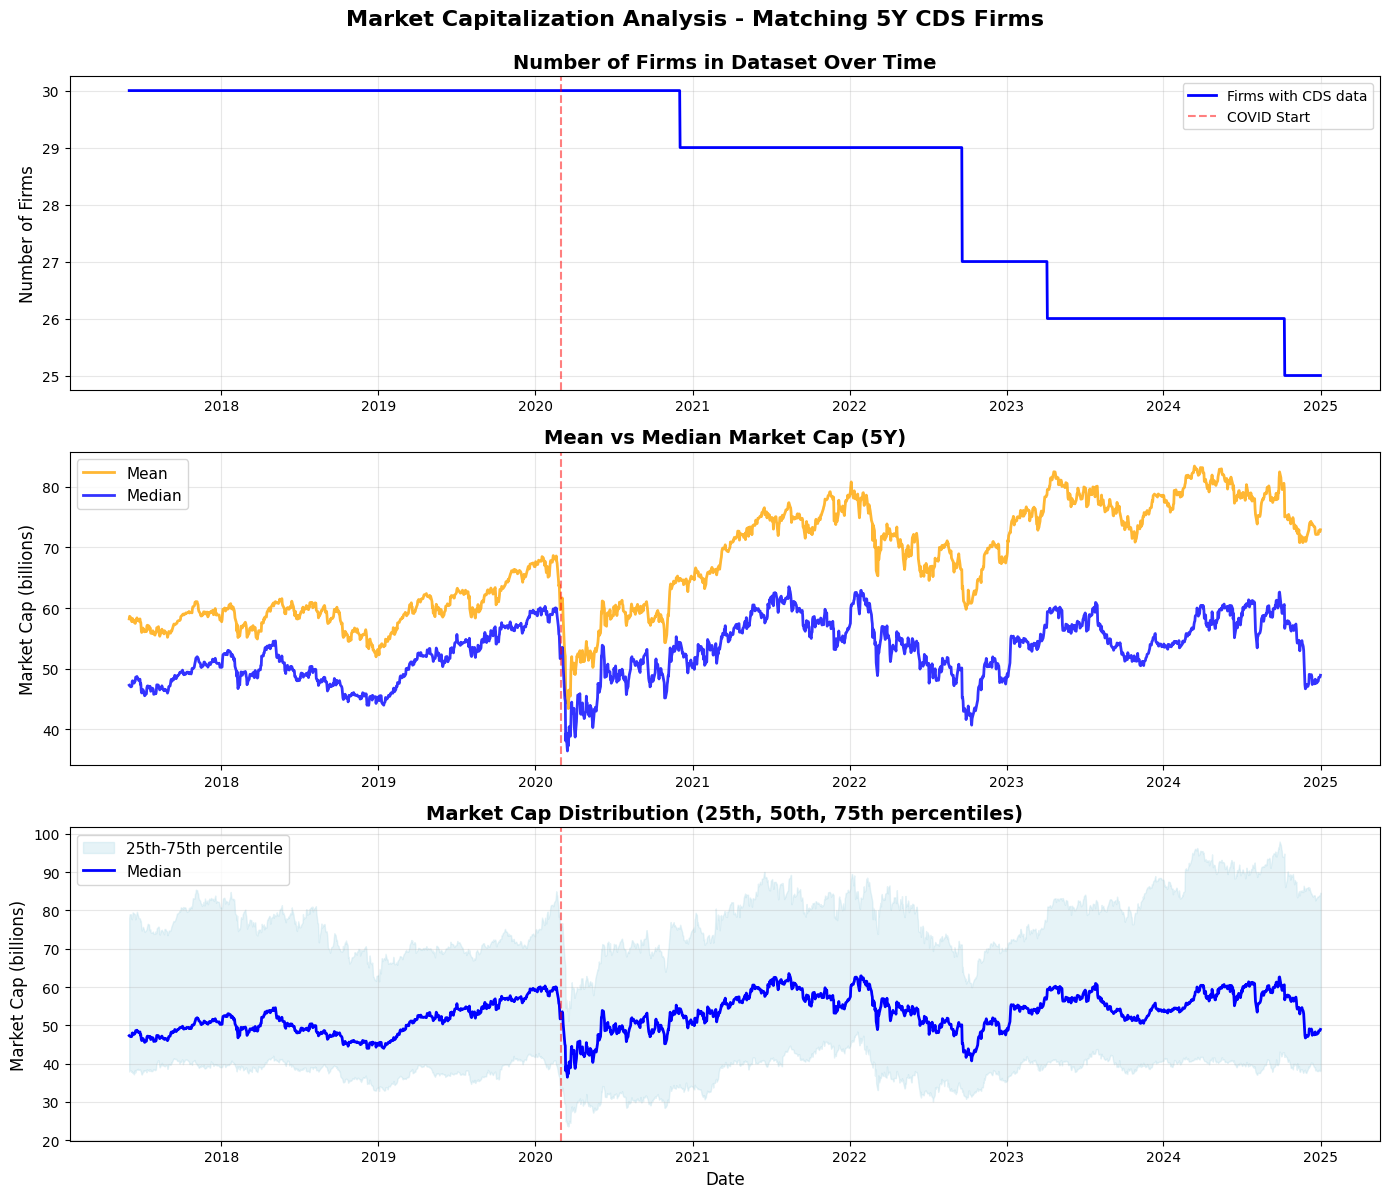

In [19]:
# Plot 1: Three-panel analysis for 5Y maturity
mktcap_stats_5y = analyze_market_cap_matching_cds_firms(maturity=5)

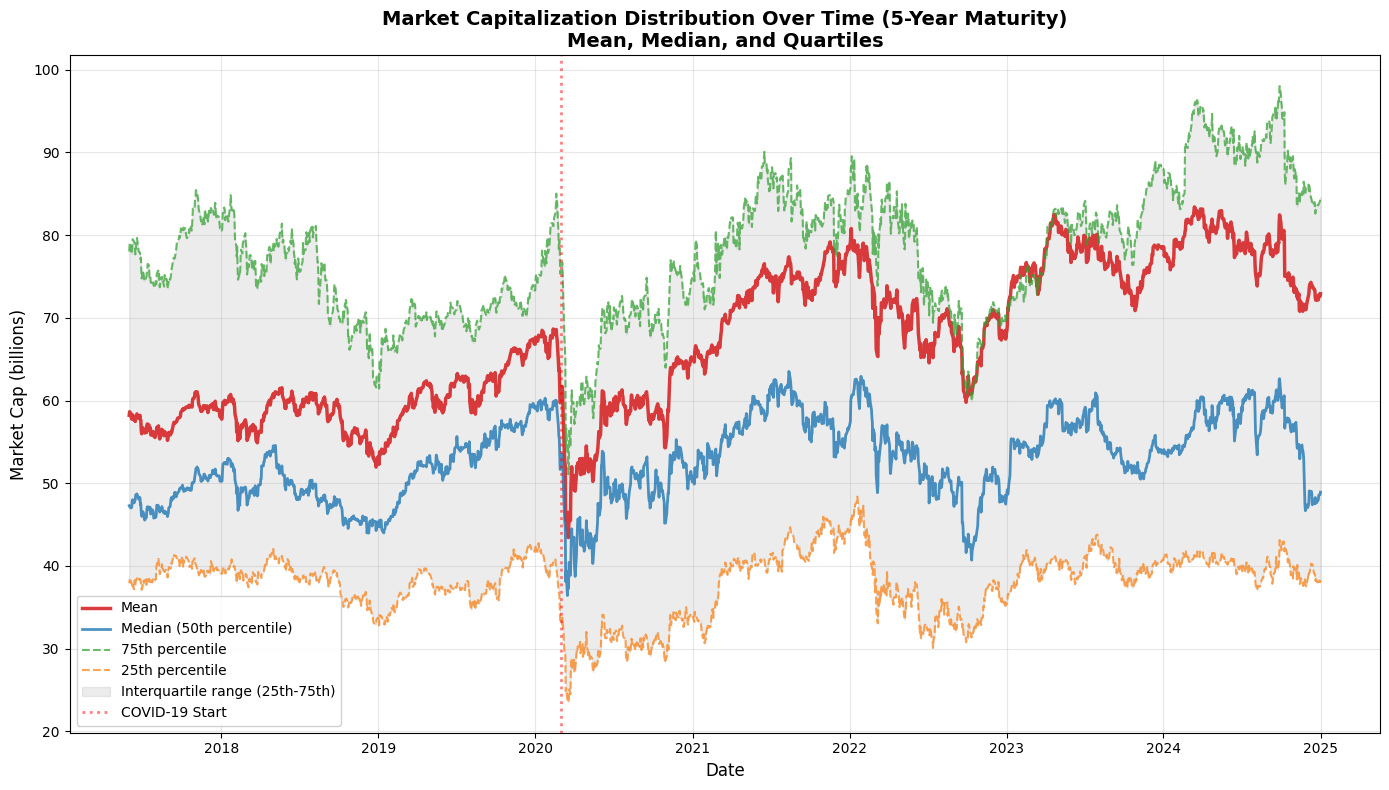


SUMMARY STATISTICS: Market Capitalization - 5Y Maturity

Period                         Mean         Median       25th %       75th %       Spread      
                               (billions)   (billions)   (billions)   (billions)   Q75-Q25     
------------------------------------------------------------------------------------------
COVID Peak (Mar-May 2020)            51.97        43.55        28.86        61.38        32.51
Banking Crisis (Jan-Mar 2023)        74.86        54.06        39.21        73.83        34.62
Recent Period (2024)                 78.08        56.61        40.03        89.90        49.88

💡 Key Insight:
   Market capitalization represents the market value of equity (shares_out × close price).
   The interquartile range (Q75-Q25) shows the spread of the middle 50% of firms.
   Only firms with 5Y CDS data are included at each point in time.


In [20]:
# Plot 2: Distribution statistics for 5Y maturity
mktcap_dist_stats_5y = plot_market_cap_distribution(maturity=5)

### Market Cap Analysis for 3-Year Maturity

These plots show market capitalization for firms that have 3-year CDS data.

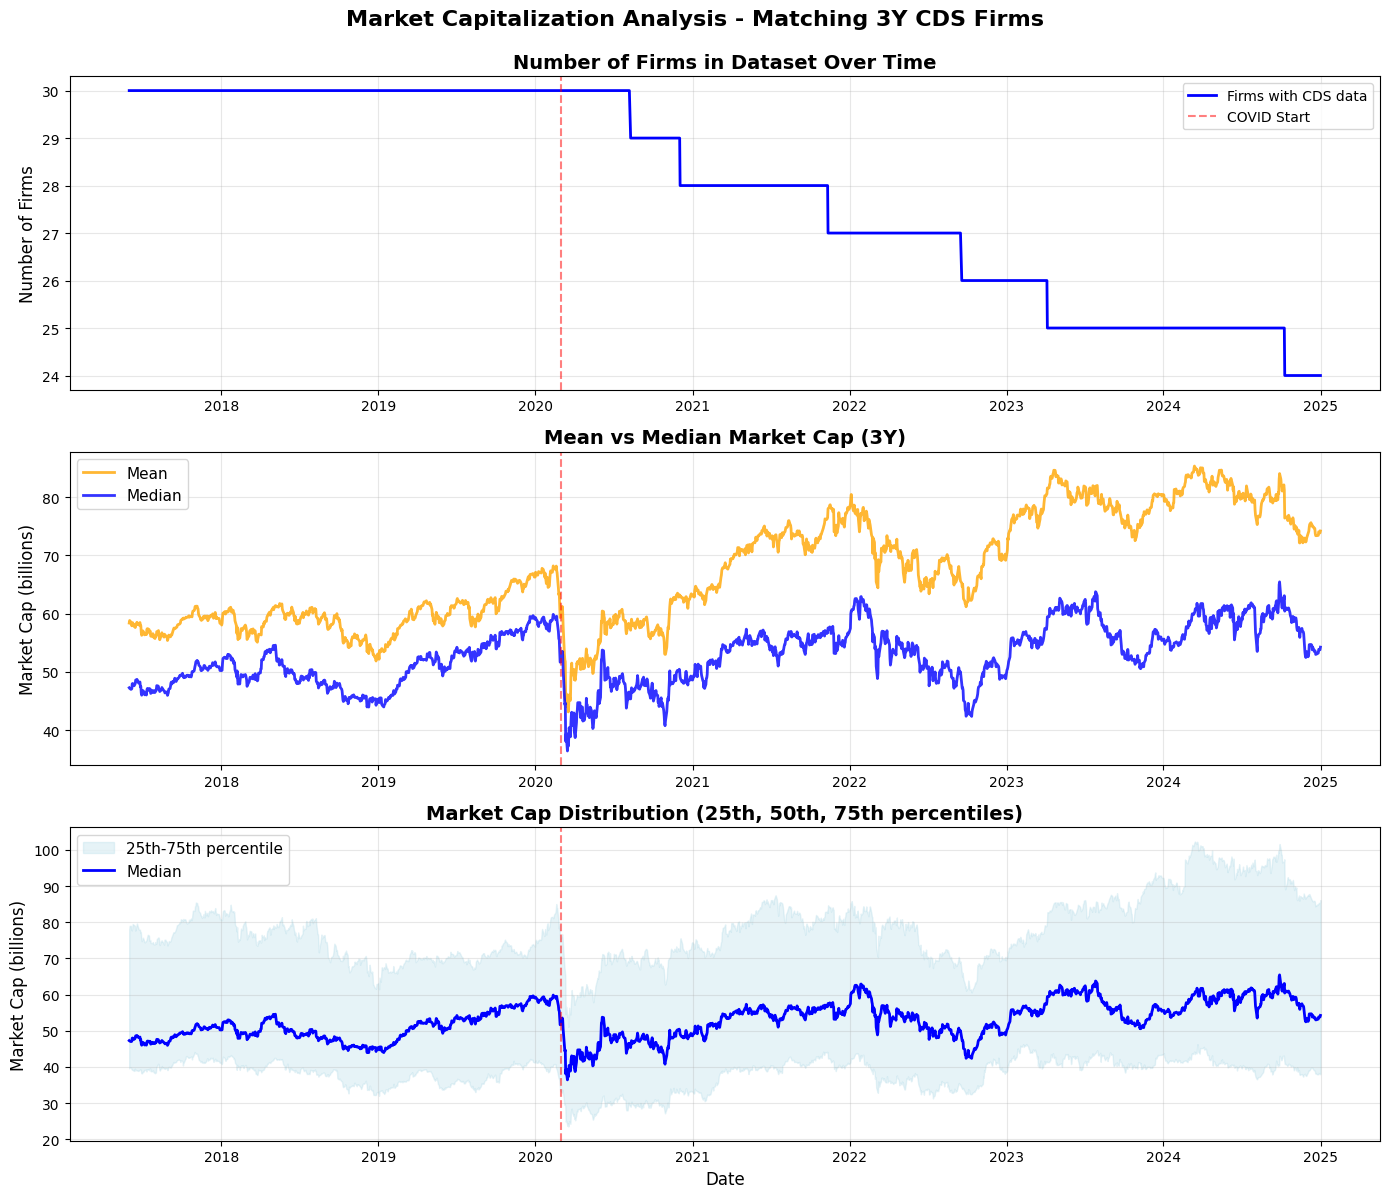

In [21]:
# Plot 1: Three-panel analysis for 3Y maturity
mktcap_stats_3y = analyze_market_cap_matching_cds_firms(maturity=3)

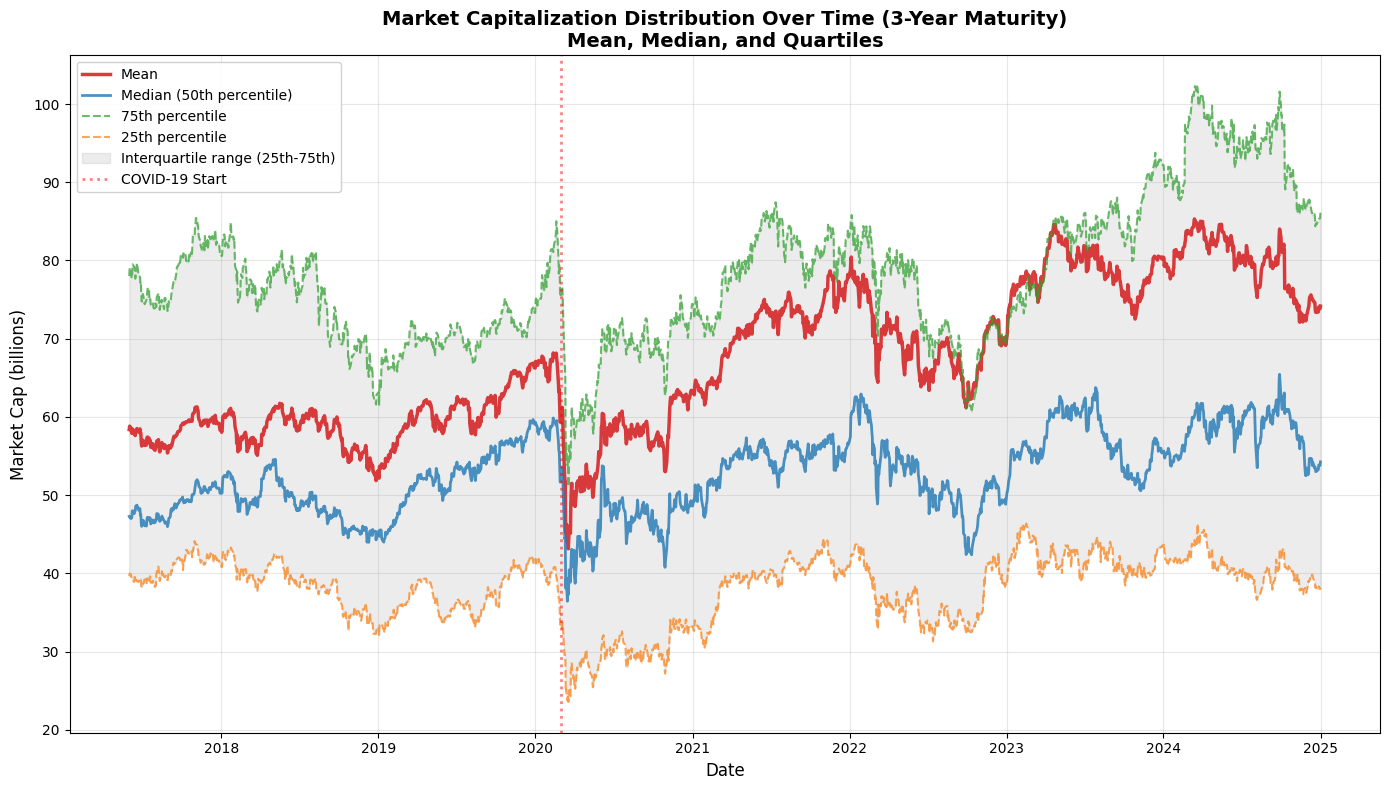


SUMMARY STATISTICS: Market Capitalization - 3Y Maturity

Period                         Mean         Median       25th %       75th %       Spread      
                               (billions)   (billions)   (billions)   (billions)   Q75-Q25     
------------------------------------------------------------------------------------------
COVID Peak (Mar-May 2020)            51.45        43.19        27.84        61.38        33.53
Banking Crisis (Jan-Mar 2023)        76.74        55.09        43.19        75.32        32.14
Recent Period (2024)                 79.68        58.30        40.67        93.85        53.18

💡 Key Insight:
   Market capitalization represents the market value of equity (shares_out × close price).
   The interquartile range (Q75-Q25) shows the spread of the middle 50% of firms.
   Only firms with 3Y CDS data are included at each point in time.


In [22]:
# Plot 2: Distribution statistics for 3Y maturity
mktcap_dist_stats_3y = plot_market_cap_distribution(maturity=3)

### Market Cap Analysis for 1-Year Maturity

These plots show market capitalization for firms that have 1-year CDS data.

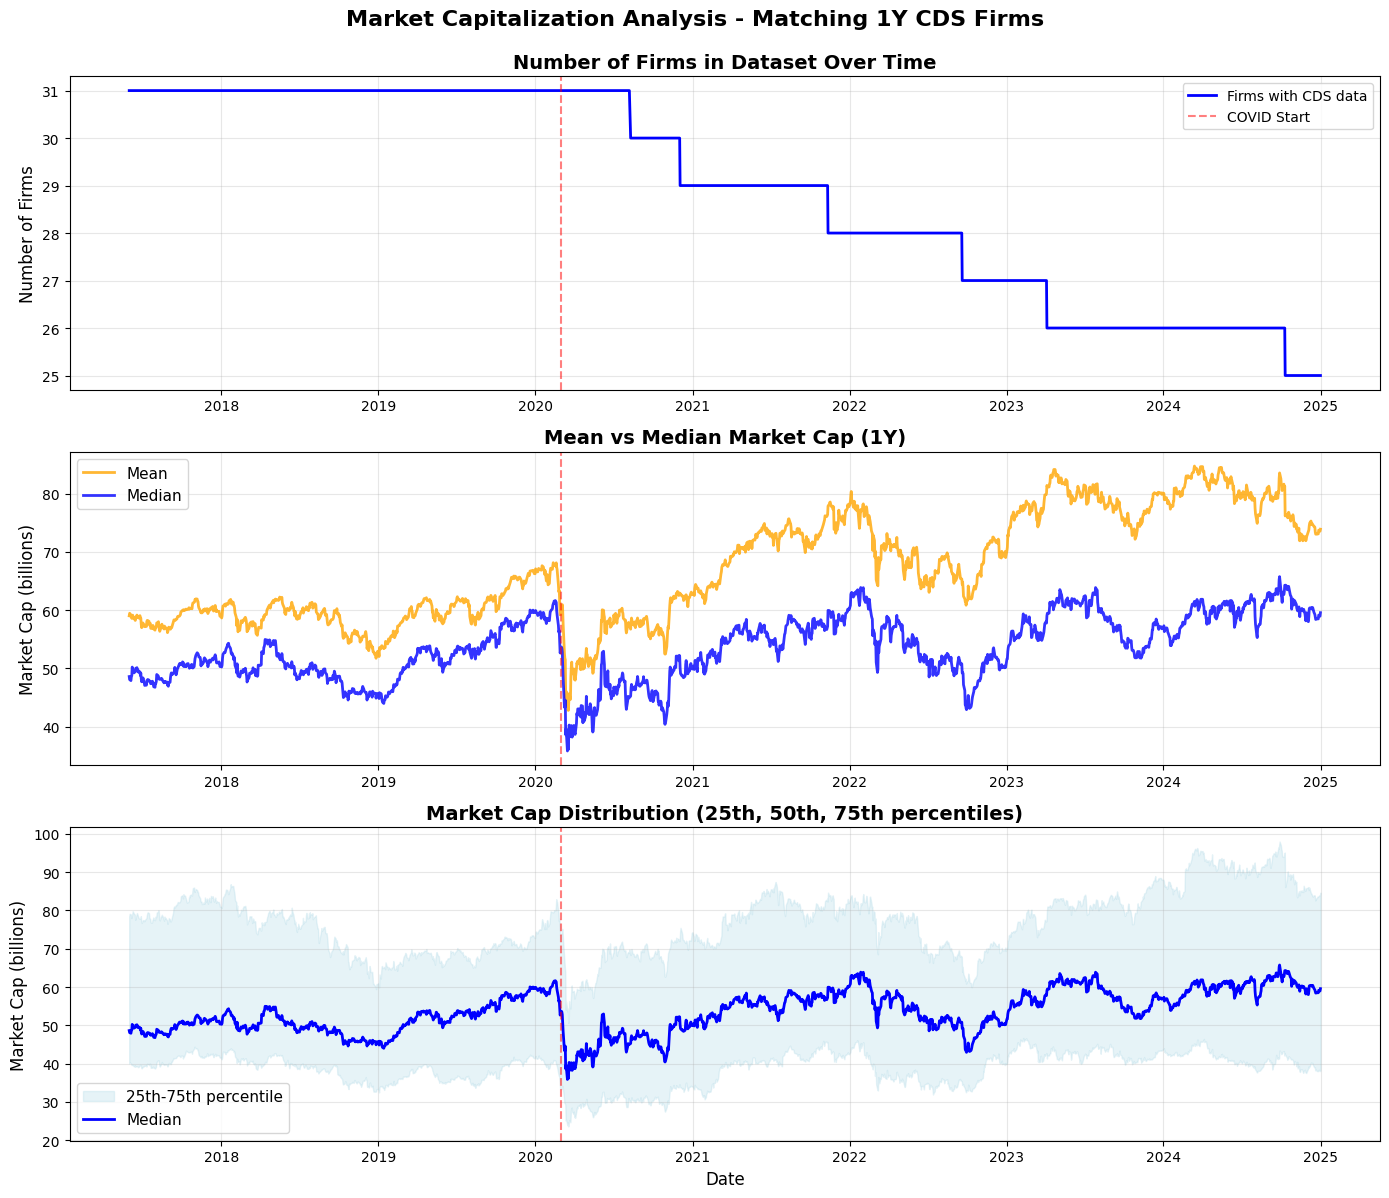

In [23]:
# Plot 1: Three-panel analysis for 1Y maturity
mktcap_stats_1y = analyze_market_cap_matching_cds_firms(maturity=1)

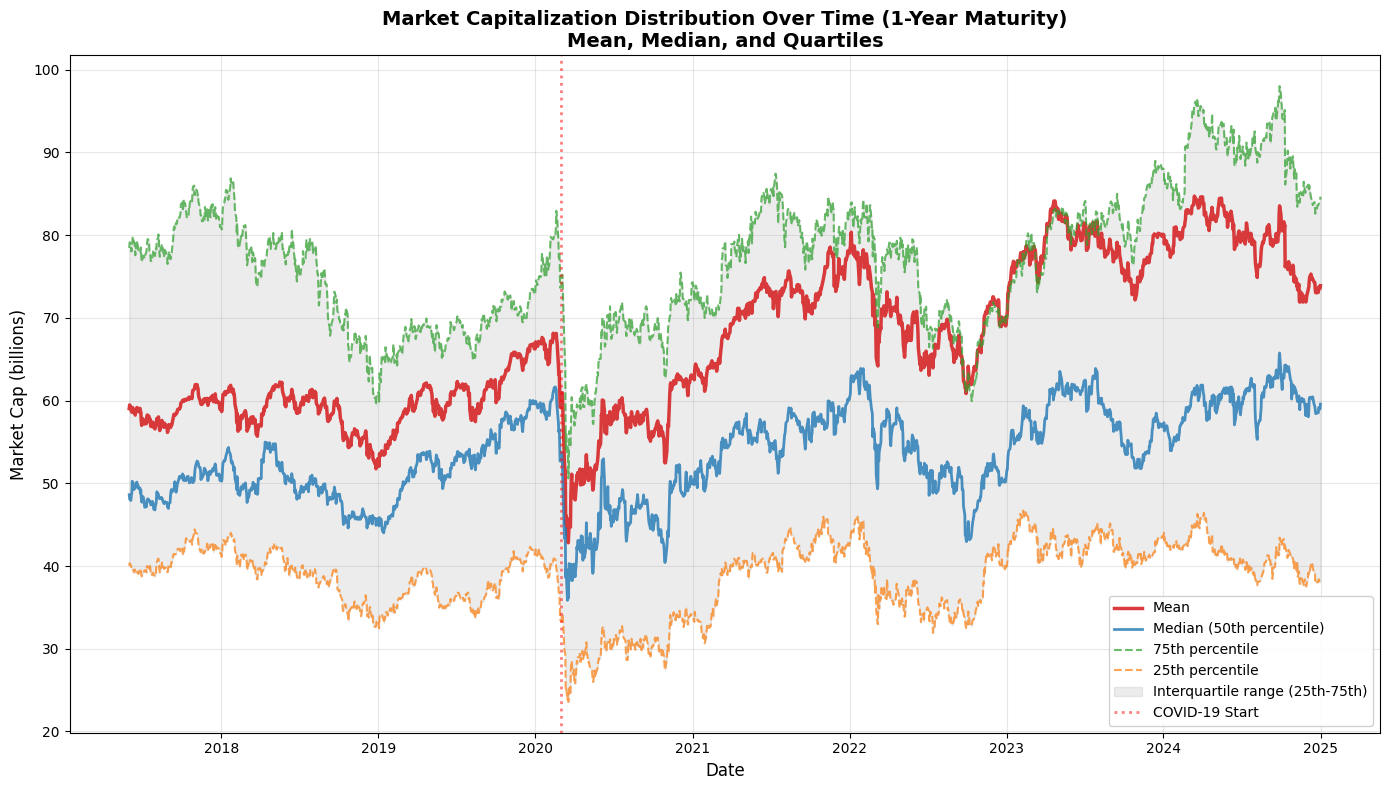


SUMMARY STATISTICS: Market Capitalization - 1Y Maturity

Period                         Mean         Median       25th %       75th %       Spread      
                               (billions)   (billions)   (billions)   (billions)   Q75-Q25     
------------------------------------------------------------------------------------------
COVID Peak (Mar-May 2020)            50.97        42.35        28.16        60.61        32.46
Banking Crisis (Jan-Mar 2023)        76.64        56.13        43.78        76.12        32.33
Recent Period (2024)                 79.34        59.95        41.25        89.98        48.73

💡 Key Insight:
   Market capitalization represents the market value of equity (shares_out × close price).
   The interquartile range (Q75-Q25) shows the spread of the middle 50% of firms.
   Only firms with 1Y CDS data are included at each point in time.


In [24]:
# Plot 2: Distribution statistics for 1Y maturity
mktcap_dist_stats_1y = plot_market_cap_distribution(maturity=1)

### Compare Market Cap Across Maturities

This section compares how market capitalization differs when we filter for different maturity CDS data availability.

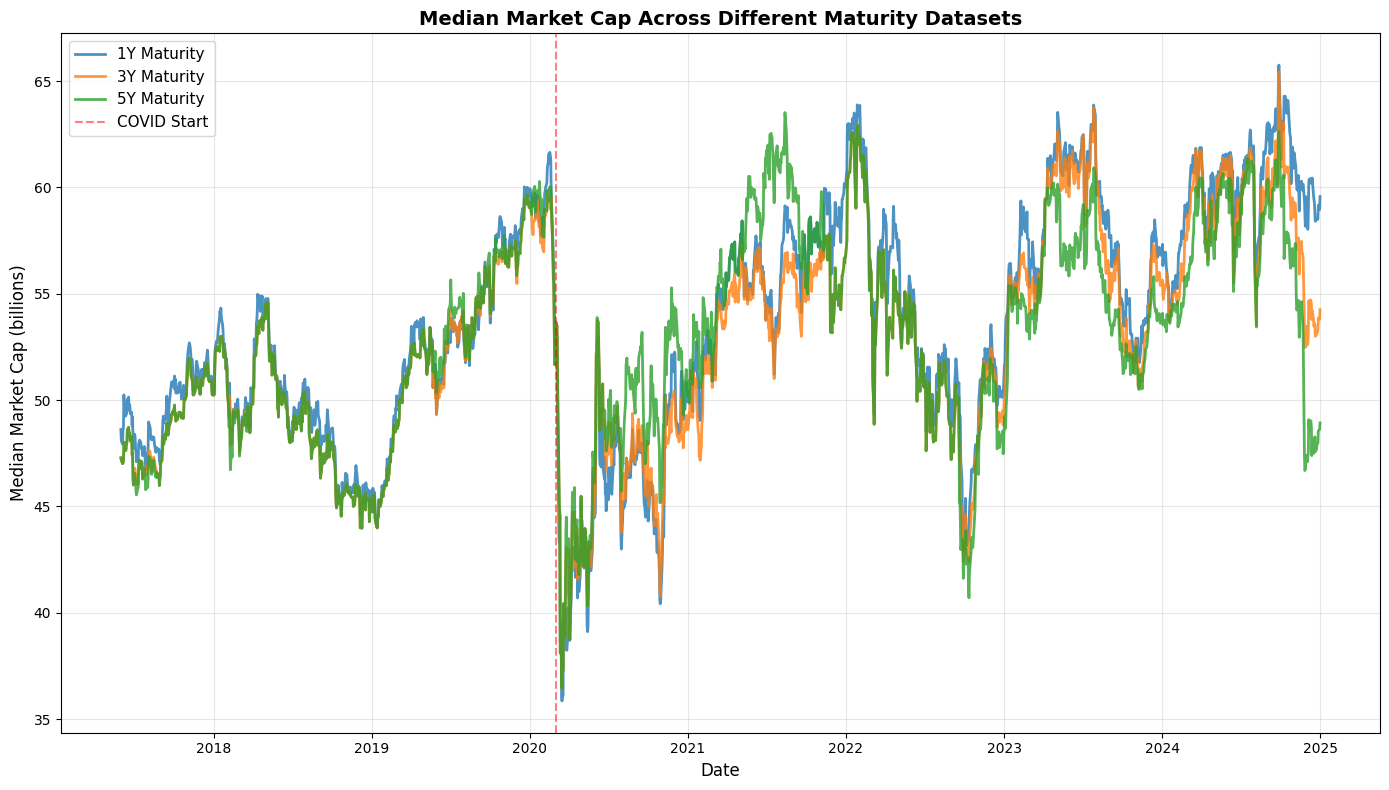

In [25]:
# Compare median market cap across all three maturities
fig, ax = plt.subplots(figsize=(14, 8))

start_date = pd.Timestamp('2017-06-01')

if 'mktcap_stats_1y' in locals() and not mktcap_stats_1y.empty:
    filtered_1y = mktcap_stats_1y[mktcap_stats_1y['date'] >= start_date]
    ax.plot(filtered_1y['date'], filtered_1y['median'], linewidth=2, label='1Y Maturity', alpha=0.8)
if 'mktcap_stats_3y' in locals() and not mktcap_stats_3y.empty:
    filtered_3y = mktcap_stats_3y[mktcap_stats_3y['date'] >= start_date]
    ax.plot(filtered_3y['date'], filtered_3y['median'], linewidth=2, label='3Y Maturity', alpha=0.8)
if 'mktcap_stats_5y' in locals() and not mktcap_stats_5y.empty:
    filtered_5y = mktcap_stats_5y[mktcap_stats_5y['date'] >= start_date]
    ax.plot(filtered_5y['date'], filtered_5y['median'], linewidth=2, label='5Y Maturity', alpha=0.8)

ax.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.5, label='COVID Start')
ax.set_title('Median Market Cap Across Different Maturity Datasets', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Median Market Cap (billions)', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Liabilities Analysis

This section analyzes **total liabilities** from the dataset, using only the firms that have CDS data for each maturity at each moment in time.

In [ ]:
def analyze_liabilities_matching_cds_firms(maturity=5, start_date='2017-06-01'):
    """
    Analyze total liabilities over time, using only the firms that have CDS data for the specified maturity.
    This creates plots matching the CDS spread distribution analysis but for liabilities.
    
    Parameters:
    -----------
    maturity : int
        The maturity in years (1, 3, or 5) - determines which firms to include at each date
    start_date : str
        Start date for the analysis (default: '2017-06-01' to match CDS plots)
    """
    # Get all unique dates in the merged data, filtered by start_date
    all_dates = df_merged[df_merged['date'] >= pd.Timestamp(start_date)]['date'].sort_values().unique()
    
    # For each date, get statistics for firms that have CDS data for this maturity
    results = []
    
    for date in all_dates:
        # Get firms with CDS data for this maturity on this date
        cds_firms = get_firms_with_cds_data(date, maturity)
        
        if len(cds_firms) == 0:
            continue
        
        # Get liabilities for these firms on this date
        date_data = df_merged[
            (df_merged['date'] == date) & 
            (df_merged['gvkey'].isin(cds_firms)) &
            (df_merged['liabilities_total'].notna())
        ]
        
        if len(date_data) == 0:
            continue
        
        # Calculate statistics (convert to billions for readability)
        liabilities_bn = date_data['liabilities_total'] / 1e9
        
        results.append({
            'date': date,
            'num_firms': len(cds_firms),
            'num_firms_with_liab': len(date_data),
            'mean': liabilities_bn.mean(),
            'median': liabilities_bn.median(),
            'q25': liabilities_bn.quantile(0.25),
            'q75': liabilities_bn.quantile(0.75),
            'std': liabilities_bn.std()
        })
    
    daily_stats = pd.DataFrame(results)
    
    # Create the plots
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    fig.suptitle(f'Total Liabilities Analysis - Matching {maturity}Y CDS Firms', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # Plot 1: Number of firms
    axes[0].plot(daily_stats['date'], daily_stats['num_firms'], linewidth=2, color='blue', label='Firms with CDS data')
    axes[0].set_title(f'Number of Firms in Dataset Over Time', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Number of Firms', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.5, label='COVID Start')
    axes[0].legend()
    
    # Plot 2: Mean vs Median liabilities
    axes[1].plot(daily_stats['date'], daily_stats['mean'], linewidth=2, label='Mean', color='orange', alpha=0.8)
    axes[1].plot(daily_stats['date'], daily_stats['median'], linewidth=2, label='Median', color='blue', alpha=0.8)
    axes[1].set_title(f'Mean vs Median Total Liabilities ({maturity}Y)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Total Liabilities (billions)', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[1].axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.5)
    
    # Plot 3: Distribution (25th, 50th, 75th percentiles)
    axes[2].fill_between(daily_stats['date'], daily_stats['q25'], daily_stats['q75'], 
                         alpha=0.3, color='lightblue', label='25th-75th percentile')
    axes[2].plot(daily_stats['date'], daily_stats['median'], linewidth=2, label='Median', color='blue')
    axes[2].set_title(f'Total Liabilities Distribution (25th, 50th, 75th percentiles)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Date', fontsize=12)
    axes[2].set_ylabel('Total Liabilities (billions)', fontsize=12)
    axes[2].legend(fontsize=11)
    axes[2].grid(True, alpha=0.3)
    axes[2].axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    return daily_stats

print("✓ Function 'analyze_liabilities_matching_cds_firms' defined")

In [ ]:
def plot_liabilities_distribution(maturity=5, start_date='2017-06-01'):
    """
    Plot total liabilities distribution over time (mean, median, and quartiles).
    Matches the companies used in CDS spread calculations for the specified maturity.
    
    Parameters:
    -----------
    maturity : int
        The maturity in years (1, 3, or 5) - determines which firms to include
    start_date : str
        Start date for the analysis (default: '2017-06-01' to match CDS plots)
    """
    # Get all unique dates, filtered by start_date
    all_dates = df_merged[df_merged['date'] >= pd.Timestamp(start_date)]['date'].sort_values().unique()
    
    results = []
    for date in all_dates:
        # Get firms with CDS data for this maturity on this date
        cds_firms = get_firms_with_cds_data(date, maturity)
        
        if len(cds_firms) == 0:
            continue
        
        # Get liabilities for these firms
        date_data = df_merged[
            (df_merged['date'] == date) & 
            (df_merged['gvkey'].isin(cds_firms)) &
            (df_merged['liabilities_total'].notna())
        ]
        
        if len(date_data) == 0:
            continue
        
        # Convert to billions for readability
        liabilities_bn = date_data['liabilities_total'] / 1e9
        
        results.append({
            'date': date,
            'mean': liabilities_bn.mean(),
            'median': liabilities_bn.median(),
            'q25': liabilities_bn.quantile(0.25),
            'q75': liabilities_bn.quantile(0.75)
        })
    
    daily_stats = pd.DataFrame(results)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Plot mean (thicker line, most important)
    ax.plot(daily_stats['date'], daily_stats['mean'], 
            linewidth=2.5, label='Mean', color='#d62728', alpha=0.9)
    
    # Plot median
    ax.plot(daily_stats['date'], daily_stats['median'], 
            linewidth=2, label='Median (50th percentile)', color='#1f77b4', alpha=0.8)
    
    # Plot 25th and 75th percentiles
    ax.plot(daily_stats['date'], daily_stats['q75'], 
            linewidth=1.5, label='75th percentile', color='#2ca02c', alpha=0.7, linestyle='--')
    ax.plot(daily_stats['date'], daily_stats['q25'], 
            linewidth=1.5, label='25th percentile', color='#ff7f0e', alpha=0.7, linestyle='--')
    
    # Fill area between 25th and 75th percentiles
    ax.fill_between(daily_stats['date'], daily_stats['q25'], daily_stats['q75'], 
                     alpha=0.15, color='gray', label='Interquartile range (25th-75th)')
    
    # Add vertical line for COVID start
    ax.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle=':', 
               alpha=0.5, linewidth=2, label='COVID-19 Start')
    
    # Labels and formatting
    ax.set_title(f'Total Liabilities Distribution Over Time ({maturity}-Year Maturity)\n' +
                 'Mean, Median, and Quartiles',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Total Liabilities (billions)', fontsize=12)
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*90}")
    print(f"SUMMARY STATISTICS: Total Liabilities - {maturity}Y Maturity")
    print(f"{'='*90}")
    
    periods = [
        ('2020-03-01', '2020-05-31', 'COVID Peak (Mar-May 2020)'),
        ('2023-01-01', '2023-03-31', 'Banking Crisis (Jan-Mar 2023)'),
        ('2024-01-01', '2024-12-31', 'Recent Period (2024)'),
    ]
    
    print(f"\n{'Period':<30} {'Mean':<12} {'Median':<12} {'25th %':<12} {'75th %':<12} {'Spread':<12}")
    print(f"{'':<30} {'(billions)':<12} {'(billions)':<12} {'(billions)':<12} {'(billions)':<12} {'Q75-Q25':<12}")
    print("-"*90)
    
    for start, end, label in periods:
        period_data = daily_stats[(daily_stats['date'] >= start) & (daily_stats['date'] <= end)]
        if not period_data.empty:
            mean_avg = period_data['mean'].mean()
            median_avg = period_data['median'].mean()
            q25_avg = period_data['q25'].mean()
            q75_avg = period_data['q75'].mean()
            spread = q75_avg - q25_avg
            
            print(f"{label:<30} {mean_avg:>11.2f}  {median_avg:>11.2f}  {q25_avg:>11.2f}  {q75_avg:>11.2f}  {spread:>11.2f}")
    
    print(f"\n💡 Key Insight:")
    print(f"   Total liabilities represent the total debt and obligations of a firm.")
    print(f"   The interquartile range (Q75-Q25) shows the spread of the middle 50% of firms.")
    print(f"   Only firms with {maturity}Y CDS data are included at each point in time.")
    
    return daily_stats

print("✓ Function 'plot_liabilities_distribution' defined")

### Liabilities Analysis for 5-Year Maturity

These plots show total liabilities for firms that have 5-year CDS data.

In [ ]:
# Plot 1: Three-panel analysis for 5Y maturity
liab_stats_5y = analyze_liabilities_matching_cds_firms(maturity=5)

In [ ]:
# Plot 2: Distribution statistics for 5Y maturity
liab_dist_stats_5y = plot_liabilities_distribution(maturity=5)

### Liabilities Analysis for 3-Year Maturity

These plots show total liabilities for firms that have 3-year CDS data.

In [ ]:
# Plot 1: Three-panel analysis for 3Y maturity
liab_stats_3y = analyze_liabilities_matching_cds_firms(maturity=3)

In [ ]:
# Plot 2: Distribution statistics for 3Y maturity
liab_dist_stats_3y = plot_liabilities_distribution(maturity=3)

### Liabilities Analysis for 1-Year Maturity

These plots show total liabilities for firms that have 1-year CDS data.

In [ ]:
# Plot 1: Three-panel analysis for 1Y maturity
liab_stats_1y = analyze_liabilities_matching_cds_firms(maturity=1)

In [ ]:
# Plot 2: Distribution statistics for 1Y maturity
liab_dist_stats_1y = plot_liabilities_distribution(maturity=1)

### Compare Liabilities Across Maturities

This section compares how total liabilities differ when we filter for different maturity CDS data availability.

In [ ]:
# Compare median liabilities across all three maturities
fig, ax = plt.subplots(figsize=(14, 8))

start_date = pd.Timestamp('2017-06-01')

if 'liab_stats_1y' in locals() and not liab_stats_1y.empty:
    filtered_1y = liab_stats_1y[liab_stats_1y['date'] >= start_date]
    ax.plot(filtered_1y['date'], filtered_1y['median'], linewidth=2, label='1Y Maturity', alpha=0.8)
if 'liab_stats_3y' in locals() and not liab_stats_3y.empty:
    filtered_3y = liab_stats_3y[liab_stats_3y['date'] >= start_date]
    ax.plot(filtered_3y['date'], filtered_3y['median'], linewidth=2, label='3Y Maturity', alpha=0.8)
if 'liab_stats_5y' in locals() and not liab_stats_5y.empty:
    filtered_5y = liab_stats_5y[liab_stats_5y['date'] >= start_date]
    ax.plot(filtered_5y['date'], filtered_5y['median'], linewidth=2, label='5Y Maturity', alpha=0.8)

ax.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.5, label='COVID Start')
ax.set_title('Median Total Liabilities Across Different Maturity Datasets', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Median Total Liabilities (billions)', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()